# **CAPÍTULO 1 Construcción del Dataset Maestro**

## **1.0 Configuración del entorno y estructura del proyecto**

Esta sección establece las bases operativas del proyecto, definiendo las rutas de almacenamiento para la base de datos de scouting (data/) y asegurando la integridad de los ficheros Excel ante posibles conflictos de escritura durante la exportación de resultados.


### **1.0.1 Imports y configuración global**

Esta celda prepara el entorno de trabajo:
- Importa librerías necesarias.
- Define rutas únicas del proyecto (carpeta `data/`).
- Define un guardado seguro para evitar errores de permisos al sobrescribir Excels.


In [1]:
# =========================================================
# 1.0.1 — Imports y configuración global
# =========================================================

# --- Standard library ---
import os
import time
import random
from io import StringIO


# --- Data ---
import numpy as np
import pandas as pd

# --- Machine Learning ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# --- Scraping / parsing (si lo usas en el notebook de extracción) ---
from bs4 import BeautifulSoup, Comment
from seleniumbase import Driver
from rapidfuzz import process, utils

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Config global ---
sns.set_style("whitegrid")
SEED = 1234
np.random.seed(SEED)

# --- Carpetas / rutas (UNIFICADO) ---
CARPETA_DATA = "data"
os.makedirs(CARPETA_DATA, exist_ok=True)

SEASON = "25/26"
MAX_AGE = 30

RUTA_DATASET = os.path.join(CARPETA_DATA, "DATASET_TRABAJO_SCOUTING.xlsx")
RUTA_TM = os.path.join(CARPETA_DATA, "transfermarkt_manual.xlsx")

# Rutas fin de contrato (separadas para no pisarlas)
RUTA_FIN_CONTRATO_AUTO   = os.path.join(CARPETA_DATA, "fin_contrato.xlsx")
RUTA_FIN_CONTRATO_MANUAL = os.path.join(CARPETA_DATA, "fin_contrato_manual.xlsx")

# --- Sleep scraping (si haces scraping en el mismo notebook) ---
SLEEP_MIN, SLEEP_MAX = 5, 8  # para FBref

# --- Ligas FBref (si procede) ---
LIGAS = {
    "Premier League": "https://fbref.com/en/comps/9/stats/Premier-League-Stats",
    "La Liga": "https://fbref.com/en/comps/12/stats/La-Liga-Stats",
    "Bundesliga": "https://fbref.com/en/comps/20/stats/Bundesliga-Stats",
    "Serie A": "https://fbref.com/en/comps/11/stats/Serie-A-Stats",
    "Ligue 1": "https://fbref.com/en/comps/13/stats/Ligue-1-Stats",
    "Primeira Liga": "https://fbref.com/en/comps/32/stats/Primeira-Liga-Stats",
    "Championship": "https://fbref.com/en/comps/10/stats/Championship-Stats"
}

# --- Claves únicas del proyecto ---
KEYS = ["Player", "Squad", "League", "season"]

def safe_write_excel(df: pd.DataFrame, path: str) -> str:
    """
    Función para el guardado seguro de archivos Excel, evitando errores de
    permisos si el archivo se encuentra en uso por el sistema.
    """
    try:
        df.to_excel(path, index=False)
        return path
    except PermissionError:
        base, ext = os.path.splitext(path)
        safe_path = f"{base}__SAFE__{ext}"
        df.to_excel(safe_path, index=False)
        return safe_path


## **1.1 Funciones auxiliares para extracción y normalización**

Se han desarrollado funciones de procesamiento de datos orientadas específicamente a la estructura de FBref y StatsBomb. El objetivo es transformar las tablas de estadísticas en registros planos y comparables.

- **Estandarización de registros:** Se unifican los nombres de jugadores, equipos y ligas para evitar duplicidades.

- **Limpieza de métricas:** Conversión automática de variables porcentuales y numéricas para su posterior tratamiento estadístico.

- **Consolidación de perfiles:** Se implementa un método de integración que permite añadir métricas avanzadas (disparos, pases, defensa) sobre la base de datos principal sin pérdida de información.

### **1.1.1 Helpers robustos FBref**


FBref a veces oculta tablas en comentarios HTML. Aquí definimos:
- Dedupe/flatten de columnas
- Extract por `table_id` (visible + comments)
- Normalizador genérico (Player/Squad/Age/Pos)
- Helpers de URLs y prefijos para merges


In [2]:
# =====================================================================================
#  CÓDIGO (HELPERS + NORMALIZACIÓN GENÉRICA)
# =====================================================================================

# Si KEYS aún no existe (por orden de ejecución), lo definimos aquí
try:
    KEYS
except NameError:
    KEYS = ("Player", "Squad", "League", "season")

def _dedupe_columns(cols):
    seen = {}
    out = []
    for c in cols:
        c = str(c).strip()
        if c in seen:
            seen[c] += 1
            out.append(f"{c}__{seen[c]}")
        else:
            seen[c] = 0
            out.append(c)
    return out

def _flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if isinstance(out.columns, pd.MultiIndex):
        new_cols = []
        for col in out.columns:
            parts = []
            for x in col:
                xs = str(x).strip()
                if xs and "Unnamed" not in xs:
                    parts.append(xs)
            new_cols.append("_".join(parts) if parts else str(col[-1]).strip())
        out.columns = new_cols

    out.columns = [str(c).replace("\n", " ").strip() for c in out.columns]
    out.columns = _dedupe_columns(out.columns)
    return out

def _find_col(df: pd.DataFrame, candidates):
    cols = list(df.columns)
    low = {c: str(c).lower() for c in cols}
    for cand in candidates:
        cand_l = str(cand).lower()
        for c in cols:
            if low[c] == cand_l:
                return c
        for c in cols:
            if low[c].endswith(f"_{cand_l}") or low[c].endswith(cand_l):
                return c
        for c in cols:
            if cand_l in low[c]:
                return c
    return None

def fbref_extract_table_from_html(html: str, table_id: str) -> pd.DataFrame:
    soup = BeautifulSoup(html, "html.parser")

    # visible
    table = soup.find("table", {"id": table_id})
    if table is not None:
        return pd.read_html(StringIO(str(table)))[0]

    # comments
    comments = soup.find_all(string=lambda text: isinstance(text, Comment))
    for c in comments:
        if table_id in c:
            sub = BeautifulSoup(c, "html.parser")
            table = sub.find("table", {"id": table_id})
            if table is not None:
                return pd.read_html(StringIO(str(table)))[0]

    raise ValueError(f"No se encontró la tabla '{table_id}' (visible ni comments).")

def derive_url(stats_url: str, section: str) -> str:
    # stats_url: .../stats/...
    if "/stats/" not in stats_url:
        raise ValueError("La URL no contiene /stats/")
    return stats_url.replace("/stats/", f"/{section}/")

def prefix_columns(df: pd.DataFrame, prefix: str, keys=KEYS) -> pd.DataFrame:
    out = df.copy()
    out.rename(columns={c: f"{prefix}{c}" for c in out.columns if c not in keys}, inplace=True)
    return out

def normalize_table_generic(df: pd.DataFrame, league_name: str, force_pos: str | None = None) -> pd.DataFrame | None:
    df = _flatten_columns(df)

    col_player = _find_col(df, ["Player"])
    col_squad  = _find_col(df, ["Squad", "Team"])
    if col_player is None or col_squad is None:
        return None

    df = df.rename(columns={col_player: "Player", col_squad: "Squad"})
    df = df[df["Player"].notna() & (df["Player"].astype(str) != "Player")].copy()

    # Nation
    col_nation = _find_col(df, ["Nation"])
    if col_nation and col_nation != "Nation":
        df.rename(columns={col_nation: "Nation"}, inplace=True)
    if "Nation" in df.columns:
        df["Nation"] = df["Nation"].astype(str).str.split(" ").str[-1]

    # Pos
    col_pos = _find_col(df, ["Pos", "Position"])
    if col_pos and col_pos != "Pos":
        df.rename(columns={col_pos: "Pos"}, inplace=True)
    if "Pos" in df.columns:
        df["Pos"] = df["Pos"].astype(str).str.strip()

    if force_pos is not None:
        df["Pos"] = force_pos

    # Age
    col_age = _find_col(df, ["Age"])
    if col_age and col_age != "Age":
        df.rename(columns={col_age: "Age"}, inplace=True)
    if "Age" in df.columns:
        df["Age"] = df["Age"].astype(str).str.split("-").str[0]
        df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

    # limpiar %
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].astype(str).str.replace("%", "", regex=False)

    df["League"] = league_name
    df["season"] = SEASON
    return df

def cast_metrics_numeric(df: pd.DataFrame, keys=KEYS) -> pd.DataFrame:
    """
    Convierte columnas (no keys) a numérico cuando sea posible.
    Versión SIN warnings (no usa errors="ignore").
    """
    out = df.copy()

    for c in out.columns:
        if c in keys:
            continue

        if out[c].dtype == "object":
            s = out[c].astype(str).str.replace(",", ".", regex=False)
            conv = pd.to_numeric(s, errors="coerce")
            ratio_ok = conv.notna().mean()

            # si al menos 20% se convierte, aceptamos la conversión
            if ratio_ok >= 0.20:
                out[c] = conv

    return out

# Avanzadas de campo (por sección)
TABLAS_CAMPO_AVANZADAS = {
    "shooting": ("stats_shooting", "Shooting_"),
    "passing": ("stats_passing", "Passing_"),
    "passing_types": ("stats_passing_types", "PassTypes_"),
    "gca": ("stats_gca", "GCA_"),
    "possession": ("stats_possession", "Possession_"),
    "defense": ("stats_defense", "Defense_"),
    "misc": ("stats_misc", "Misc_"),
}

# ============================================================
# HOTFIX UPSERT (pisar versión vieja con .where)
# - dedupe por KEYS
# - reindex add al índice de base
# - rellena NaN con np.where (sin InvalidIndexError)
# ============================================================

def upsert_by_keys(base: pd.DataFrame, add: pd.DataFrame, keys=KEYS) -> pd.DataFrame:
    if add is None or add.empty:
        return base

    base = base.copy()
    add = add.copy()

    # 1) asegurar KEYS
    for k in keys:
        if k not in base.columns:
            raise ValueError(f"Base no tiene key: {k}")
        if k not in add.columns:
            raise ValueError(f"Add no tiene key: {k}")

    # 2) normalizar KEYS (evita duplicados por espacios raros)
    for k in keys:
        base[k] = base[k].astype(str).str.strip()
        add[k]  = add[k].astype(str).str.strip()

    # 3) dedupe (CLAVE para evitar InvalidIndexError)
    base = base.drop_duplicates(subset=list(keys), keep="first").copy()
    add  = add.drop_duplicates(subset=list(keys), keep="last").copy()

    base_i = base.set_index(list(keys), drop=False)
    add_i  = add.set_index(list(keys), drop=False)

    # 4) alinear add al índice de base (mismo orden y mismo tamaño)
    add_i = add_i.reindex(base_i.index)

    # 5) upsert: añadir cols y rellenar solo NaNs
    for col in add_i.columns:
        if col in keys:
            continue

        if col not in base_i.columns:
            base_i[col] = np.nan

        base_vals = base_i[col].to_numpy()
        add_vals  = add_i[col].to_numpy()

        mask = pd.isna(base_vals)
        base_i[col] = np.where(mask, add_vals, base_vals)

    return base_i.reset_index(drop=True)

## **1.2 Generación del Dataset Base por Ligas**

En esta fase se realiza la ingesta masiva de las "Cinco Grandes Ligas" europeas más la Primeira Liga y la Championship. Se filtran automáticamente jugadores mayores de 30 años para centrar el análisis en activos con valor de mercado y potencial de reventa.

### **1.2.1 Generación del Dataset Base**

Genera el archivo único del proyecto:
`data/DATASET_TRABAJO_SCOUTING.xlsx`

Incluye:
- Standard Stats (jugadores de campo)

- Si Excel está abierto, se guardará como __SAFE__

In [3]:
# =====================================================================================
# Standard + Keeper)
# =====================================================================================

# Si SLEEP_MIN / SLEEP_MAX aún no existen, los definimos aquí
try:
    SLEEP_MIN
    SLEEP_MAX
except NameError:
    SLEEP_MIN, SLEEP_MAX = 5, 8

# Retry helper (FBref a veces carga sin tabla a la primera)
def _get_html_with_retry(driver, url, tries=3, wait_min=5, wait_max=8):
    last_html = ""
    for i in range(tries):
        driver.get(url)
        time.sleep(random.uniform(wait_min, wait_max))
        html = driver.get_page_source()
        last_html = html
        # señal simple de que “hay página”
        if html and len(html) > 5000:
            return html
    return last_html

driver = Driver(browser="chrome", uc=True, headless=True)

all_standard = []
all_keeper = []

try:
    for league_name, stats_url in LIGAS.items():

        # ---------- STANDARD ----------
        print(f"- Extrayendo Standard Stats: {league_name}...")

        html = _get_html_with_retry(driver, stats_url, tries=3, wait_min=SLEEP_MIN, wait_max=SLEEP_MAX)

        try:
            df_std_raw = fbref_extract_table_from_html(html, "stats_standard")
        except Exception as e:
            print(f"- {league_name}: Standard falló al extraer tabla (ID stats_standard) ({type(e).__name__}). - Se continúa.")
            continue

        df_std = normalize_table_generic(df_std_raw, league_name)

        if df_std is None or df_std.empty:
            print(f"- {league_name}: Standard sin llaves/ vacío. - Se continúa.")
        else:
            # dedupe fuerte por KEYS
            df_std.drop_duplicates(subset=list(KEYS), keep="first", inplace=True)
            all_standard.append(df_std)
            print(f"- {league_name} Standard OK ({len(df_std)} jug.)")

        # ---------- KEEPER (BÁSICO) ----------
        keeper_url = derive_url(stats_url, "keepers")

        try:
            print(f"- Extrayendo Keeper: {league_name}...")

            html_k = _get_html_with_retry(driver, keeper_url, tries=3, wait_min=SLEEP_MIN, wait_max=SLEEP_MAX)

            df_k_raw = fbref_extract_table_from_html(html_k, "stats_keeper")
            df_k = normalize_table_generic(df_k_raw, league_name, force_pos="GK")

            if df_k is None or df_k.empty:
                print(f"- {league_name}: Keeper sin llaves/ vacío. - Se continúa.")
            else:
                df_k.drop_duplicates(subset=list(KEYS), keep="first", inplace=True)
                all_keeper.append(df_k)
                print(f"- {league_name} Keeper OK ({len(df_k)} porteros)")

        except Exception as e:
            print(f"- {league_name}: Keeper falló ({type(e).__name__}). - Se continúa.")

    if len(all_standard) == 0:
        raise ValueError("No se extrajo ninguna tabla Standard en ninguna liga.")

    # ---------- CONSOLIDACIÓN STANDARD ----------
    df_global = pd.concat(all_standard, ignore_index=True)

    if "Age" in df_global.columns:
        df_global = df_global[df_global["Age"].notna() & (df_global["Age"] < MAX_AGE)].copy()

    df_global.drop_duplicates(subset=list(KEYS), keep="first", inplace=True)
    df_dataset = df_global.copy()

    # ---------- MERGE KEEPER (solo una vez; luego usaremos UPSERT en avanzadas) ----------
    df_keeper = pd.concat(all_keeper, ignore_index=True) if len(all_keeper) else pd.DataFrame()

    if not df_keeper.empty:
        df_keeper = cast_metrics_numeric(df_keeper, keys=KEYS)
        df_keeper = prefix_columns(df_keeper, "Keeper_")

        # evita MergeError por duplicados
        df_keeper.drop_duplicates(subset=list(KEYS), keep="first", inplace=True)

        df_dataset = df_dataset.merge(df_keeper, on=list(KEYS), how="left")
        print("- Keeper merge aplicado.")
    else:
        print("- Keeper vacío. Dataset sigue correcto.")

    df_dataset.drop_duplicates(subset=list(KEYS), keep="first", inplace=True)

    # ---------- GUARDADO ÚNICO ----------
    ruta_guardado = safe_write_excel(df_dataset, RUTA_DATASET)

    print("\n==============================================")
    print(f"- DATASET_TRABAJO_SCOUTING.xlsx (BASE) generado")
    print(f"- Archivo: {ruta_guardado}")
    print(f"- Filas: {len(df_dataset)} | Columnas: {df_dataset.shape[1]}")
    if ruta_guardado != RUTA_DATASET:
        print("- Excel estaba abierto/bloqueado. Guardado como __SAFE__.")
    print("==============================================")

except Exception as e:
    print(f"- Error: {repr(e)}")

finally:
    driver.quit()
    print("- Driver cerrado correctamente.")

- Extrayendo Standard Stats: Premier League...
- Premier League Standard OK (532 jug.)
- Extrayendo Keeper: Premier League...
- Premier League Keeper OK (34 porteros)
- Extrayendo Standard Stats: La Liga...
- La Liga Standard OK (568 jug.)
- Extrayendo Keeper: La Liga...
- La Liga Keeper OK (31 porteros)
- Extrayendo Standard Stats: Bundesliga...
- Bundesliga Standard OK (487 jug.)
- Extrayendo Keeper: Bundesliga...
- Bundesliga Keeper OK (26 porteros)
- Extrayendo Standard Stats: Serie A...
- Serie A Standard OK (577 jug.)
- Extrayendo Keeper: Serie A...
- Serie A Keeper OK (39 porteros)
- Extrayendo Standard Stats: Ligue 1...
- Ligue 1 Standard OK (533 jug.)
- Extrayendo Keeper: Ligue 1...
- Ligue 1 Keeper OK (36 porteros)
- Extrayendo Standard Stats: Primeira Liga...
- Primeira Liga Standard OK (543 jug.)
- Extrayendo Keeper: Primeira Liga...
- Primeira Liga Keeper OK (35 porteros)
- Extrayendo Standard Stats: Championship...
- Championship Standard OK (774 jug.)
- Extrayendo Keeper

## **1.3 Enriquecimiento por rol (Avanzadas)**




### **1.3.1 Función de enriquecimiento por liga**

Este bloque NO procesa todas las ligas a la vez.
Se ejecuta una liga cada vez para evitar:
- tiempos largos,
- fallos a mitad,
- bloqueos.

Añade al dataset:
- Keeper Advanced (porteros) → `KeeperAdv_...`
- Tablas avanzadas de campo (Shooting, Passing, Defense, etc.) → prefijos

Técnica:
- Usa UPSERT (rellena NaN) para evitar `MergeError` y duplicados.
"""


In [6]:
# =====================================================================================
# CÓDIGO (FUNCION: ENRIQUECER UNA LIGA)
# =====================================================================================

def enriquecer_una_liga(league_name: str):
    if league_name not in LIGAS:
        raise ValueError(f"- Liga no válida: {league_name}")

    # --- Lógica de carga inteligente ---
    # Si existe un archivo __SAFE__, lo usamos como base para no perder datos previos
    ruta_safe = RUTA_DATASET.replace(".xlsx", "__SAFE__.xlsx")
    ruta_lectura = ruta_safe if os.path.exists(ruta_safe) else RUTA_DATASET

    if not os.path.exists(ruta_lectura):
        raise FileNotFoundError(f"- No existe el dataset base en {RUTA_DATASET}. Ejecuta la CELDA 2 primero.")

    print(f"- Cargando base desde: {ruta_lectura}")
    df_dataset = pd.read_excel(ruta_lectura)
    
    stats_url = LIGAS[league_name]
    driver = Driver(browser="chrome", uc=True, headless=True)
    piezas = []

    try:
        # =======================
        # 1) KEEPER ADV
        # =======================
        keeperadv_url = derive_url(stats_url, "keepersadv")
        try:
            print(f"- [{league_name}] Extrayendo KeeperAdv...")
            driver.get(keeperadv_url)
            time.sleep(random.uniform(SLEEP_MIN, SLEEP_MAX))
            html_ka = driver.get_page_source()

            # Intentamos extraer. Si da ValueError por tabla vacía, el try/except lo captura
            df_ka_raw = fbref_extract_table_from_html(html_ka, "stats_keeper_adv")
            df_ka = normalize_table_generic(df_ka_raw, league_name, force_pos="GK")

            if df_ka is not None and not df_ka.empty:
                df_ka = cast_metrics_numeric(df_ka, keys=KEYS)
                df_ka = prefix_columns(df_ka, "KeeperAdv_")
                piezas.append(df_ka)
                print(f"- [{league_name}] KeeperAdv OK")
            else:
                print(f"- [{league_name}] KeeperAdv vacío o sin datos válidos.")
        except (ValueError, Exception) as e:
            print(f"- [{league_name}] KeeperAdv saltado: No disponible o error en tabla ({type(e).__name__}).")

        # =======================
        # 2) TABLAS AVANZADAS CAMPO
        # =======================
        for section, (table_id, prefix) in TABLAS_CAMPO_AVANZADAS.items():
            url_section = derive_url(stats_url, section)
            try:
                print(f"- [{league_name}] Extrayendo {section}...")
                driver.get(url_section)
                time.sleep(random.uniform(SLEEP_MIN, SLEEP_MAX))
                html = driver.get_page_source()

                df_raw = fbref_extract_table_from_html(html, table_id)
                df_norm = normalize_table_generic(df_raw, league_name)

                if df_norm is not None and not df_norm.empty:
                    df_norm = cast_metrics_numeric(df_norm, keys=KEYS)
                    df_norm = prefix_columns(df_norm, prefix)
                    piezas.append(df_norm)
                    print(f"- [{league_name}] {section} OK")
                else:
                    print(f"- [{league_name}] {section} vacía.")

            except Exception as e:
                print(f"- [{league_name}] {section} falló ({type(e).__name__}). - Continúa.")

        # =======================
        # 3) CONSOLIDACIÓN (UPSERT)
        # =======================
        if not piezas:
            print(f"- [{league_name}] No se pudo extraer ninguna pieza nueva.")
            return

        print(f"- Consolidando {len(piezas)} nuevas tablas mediante Upsert...")
        df_out = df_dataset.copy()

        for df_add in piezas:
            df_out = upsert_by_keys(df_out, df_add, keys=KEYS)

        # Limpieza final de duplicados por si acaso
        df_out.drop_duplicates(subset=list(KEYS), keep="first", inplace=True)

        # Guardado
        ruta_guardado = safe_write_excel(df_out, RUTA_DATASET)

        print("\n==============================================")
        print(f"- Enriquecimiento completado: {league_name}")
        print(f"- Guardado en: {ruta_guardado}")
        print(f"- Filas: {len(df_out)} | Columnas: {df_out.shape[1]}")
        print("==============================================")

    finally:
        driver.quit()
        print(f"- Driver cerrado [{league_name}].")

### **1.3.2 Premier League — Enriquecimiento avanzado**


In [7]:
enriquecer_una_liga("Premier League")

- Cargando base desde: data\DATASET_TRABAJO_SCOUTING.xlsx
- [Premier League] Extrayendo KeeperAdv...
- [Premier League] KeeperAdv OK
- [Premier League] Extrayendo shooting...
- [Premier League] shooting OK
- [Premier League] Extrayendo passing...
- [Premier League] passing OK
- [Premier League] Extrayendo passing_types...
- [Premier League] passing_types OK
- [Premier League] Extrayendo gca...
- [Premier League] gca OK
- [Premier League] Extrayendo possession...
- [Premier League] possession OK
- [Premier League] Extrayendo defense...
- [Premier League] defense OK
- [Premier League] Extrayendo misc...
- [Premier League] misc OK
- Consolidando 8 nuevas tablas mediante Upsert...

- Enriquecimiento completado: Premier League
- Guardado en: data\DATASET_TRABAJO_SCOUTING.xlsx
- Filas: 3236 | Columnas: 242
- Driver cerrado [Premier League].


### **1.3.3 La Liga — Enriquecimiento avanzado**


In [8]:
enriquecer_una_liga("La Liga")


- Cargando base desde: data\DATASET_TRABAJO_SCOUTING.xlsx
- [La Liga] Extrayendo KeeperAdv...
- [La Liga] KeeperAdv OK
- [La Liga] Extrayendo shooting...
- [La Liga] shooting OK
- [La Liga] Extrayendo passing...
- [La Liga] passing OK
- [La Liga] Extrayendo passing_types...
- [La Liga] passing_types OK
- [La Liga] Extrayendo gca...
- [La Liga] gca OK
- [La Liga] Extrayendo possession...
- [La Liga] possession OK
- [La Liga] Extrayendo defense...
- [La Liga] defense OK
- [La Liga] Extrayendo misc...
- [La Liga] misc OK
- Consolidando 8 nuevas tablas mediante Upsert...

- Enriquecimiento completado: La Liga
- Guardado en: data\DATASET_TRABAJO_SCOUTING.xlsx
- Filas: 3236 | Columnas: 242
- Driver cerrado [La Liga].


### **1.3.4 Bundesliga — Enriquecimiento avanzado**


In [9]:
enriquecer_una_liga("Bundesliga")


- Cargando base desde: data\DATASET_TRABAJO_SCOUTING.xlsx
- [Bundesliga] Extrayendo KeeperAdv...
- [Bundesliga] KeeperAdv OK
- [Bundesliga] Extrayendo shooting...
- [Bundesliga] shooting OK
- [Bundesliga] Extrayendo passing...
- [Bundesliga] passing OK
- [Bundesliga] Extrayendo passing_types...
- [Bundesliga] passing_types OK
- [Bundesliga] Extrayendo gca...
- [Bundesliga] gca OK
- [Bundesliga] Extrayendo possession...
- [Bundesliga] possession OK
- [Bundesliga] Extrayendo defense...
- [Bundesliga] defense OK
- [Bundesliga] Extrayendo misc...
- [Bundesliga] misc OK
- Consolidando 8 nuevas tablas mediante Upsert...

- Enriquecimiento completado: Bundesliga
- Guardado en: data\DATASET_TRABAJO_SCOUTING.xlsx
- Filas: 3236 | Columnas: 242
- Driver cerrado [Bundesliga].


### **1.3.5 Serie A — Enriquecimiento avanzado**


In [10]:
enriquecer_una_liga("Serie A")



- Cargando base desde: data\DATASET_TRABAJO_SCOUTING.xlsx
- [Serie A] Extrayendo KeeperAdv...
- [Serie A] KeeperAdv OK
- [Serie A] Extrayendo shooting...
- [Serie A] shooting OK
- [Serie A] Extrayendo passing...
- [Serie A] passing OK
- [Serie A] Extrayendo passing_types...
- [Serie A] passing_types OK
- [Serie A] Extrayendo gca...
- [Serie A] gca OK
- [Serie A] Extrayendo possession...
- [Serie A] possession OK
- [Serie A] Extrayendo defense...
- [Serie A] defense OK
- [Serie A] Extrayendo misc...
- [Serie A] misc OK
- Consolidando 8 nuevas tablas mediante Upsert...

- Enriquecimiento completado: Serie A
- Guardado en: data\DATASET_TRABAJO_SCOUTING.xlsx
- Filas: 3236 | Columnas: 242
- Driver cerrado [Serie A].


### **1.3.6 Ligue 1 — Enriquecimiento avanzado**


In [11]:
enriquecer_una_liga("Ligue 1")


- Cargando base desde: data\DATASET_TRABAJO_SCOUTING.xlsx
- [Ligue 1] Extrayendo KeeperAdv...
- [Ligue 1] KeeperAdv OK
- [Ligue 1] Extrayendo shooting...
- [Ligue 1] shooting OK
- [Ligue 1] Extrayendo passing...
- [Ligue 1] passing OK
- [Ligue 1] Extrayendo passing_types...
- [Ligue 1] passing_types OK
- [Ligue 1] Extrayendo gca...
- [Ligue 1] gca OK
- [Ligue 1] Extrayendo possession...
- [Ligue 1] possession OK
- [Ligue 1] Extrayendo defense...
- [Ligue 1] defense OK
- [Ligue 1] Extrayendo misc...
- [Ligue 1] misc OK
- Consolidando 8 nuevas tablas mediante Upsert...

- Enriquecimiento completado: Ligue 1
- Guardado en: data\DATASET_TRABAJO_SCOUTING.xlsx
- Filas: 3236 | Columnas: 242
- Driver cerrado [Ligue 1].


### **1.3.7 Primeira Liga — Enriquecimiento avanzado**


In [12]:
enriquecer_una_liga("Primeira Liga")

- Cargando base desde: data\DATASET_TRABAJO_SCOUTING.xlsx
- [Primeira Liga] Extrayendo KeeperAdv...
- [Primeira Liga] KeeperAdv OK
- [Primeira Liga] Extrayendo shooting...
- [Primeira Liga] shooting OK
- [Primeira Liga] Extrayendo passing...
- [Primeira Liga] passing OK
- [Primeira Liga] Extrayendo passing_types...
- [Primeira Liga] passing_types OK
- [Primeira Liga] Extrayendo gca...
- [Primeira Liga] gca OK
- [Primeira Liga] Extrayendo possession...
- [Primeira Liga] possession OK
- [Primeira Liga] Extrayendo defense...
- [Primeira Liga] defense OK
- [Primeira Liga] Extrayendo misc...
- [Primeira Liga] misc OK
- Consolidando 8 nuevas tablas mediante Upsert...

- Enriquecimiento completado: Primeira Liga
- Guardado en: data\DATASET_TRABAJO_SCOUTING.xlsx
- Filas: 3236 | Columnas: 242
- Driver cerrado [Primeira Liga].


### **1.3.8 Championship — Enriquecimiento avanzado**


In [13]:
enriquecer_una_liga("Championship")

- Cargando base desde: data\DATASET_TRABAJO_SCOUTING.xlsx
- [Championship] Extrayendo KeeperAdv...
- [Championship] KeeperAdv OK
- [Championship] Extrayendo shooting...
- [Championship] shooting OK
- [Championship] Extrayendo passing...
- [Championship] passing OK
- [Championship] Extrayendo passing_types...
- [Championship] passing_types OK
- [Championship] Extrayendo gca...
- [Championship] gca OK
- [Championship] Extrayendo possession...
- [Championship] possession OK
- [Championship] Extrayendo defense...
- [Championship] defense OK
- [Championship] Extrayendo misc...
- [Championship] misc OK
- Consolidando 8 nuevas tablas mediante Upsert...

- Enriquecimiento completado: Championship
- Guardado en: data\DATASET_TRABAJO_SCOUTING.xlsx
- Filas: 3236 | Columnas: 242
- Driver cerrado [Championship].


## **1.4 Integración de mercado y variables contractuales**

Para que el modelo tenga aplicabilidad real en una Dirección Deportiva, se integran datos económicos externos.

- **Valoración de Mercado:** Sincronización con valores de mercado estimados en millones de euros.

- **Situación Contractual:** Identificación de jugadores que finalizan contrato en 2025 o 2026, marcándolos como "Oportunidades de Mercado" (Agentes Libres).

### **1.4.1 Limpieza y estandarización Transfermarkt**

En este bloque se limpia el fichero manual `transfermarkt_manual.xlsx`:

- Conversión del valor de mercado a formato numérico en millones de euros (`Valor_M€`).
- Eliminación de registros con nombres incompletos (ej. "A.", "A").
- Generación de un identificador normalizado (`name_match`) para facilitar el cruce posterior.

Salida:
- `data/02_precios_limpios.xlsx` (dataset limpio para integración en el dataset maestro).

In [14]:
# ==============================================================================
# 1.4.1 Transfermarkt -> 02_precios_limpios.xlsx (Valor_M€, Pie, Altura_cm)
# ==============================================================================

ruta_tm = os.path.join(CARPETA_DATA, "transfermarkt_manual.xlsx")
if not os.path.exists(ruta_tm):
    raise FileNotFoundError(f"No existe: {ruta_tm}")

df_tm = pd.read_excel(ruta_tm)

# Columnas exactas según tu ejemplo
COL_NOMBRE = "Jugador"
COL_VALOR  = "Valor (M€)"
COL_PIE    = "Pie Preferido"
COL_ALT    = "Altura (cm)"

for c in [COL_NOMBRE, COL_VALOR]:
    if c not in df_tm.columns:
        raise ValueError(f"Falta columna en transfermarkt_manual.xlsx: {c}")

# Valor numérico robusto
df_tm["Valor_M€"] = pd.to_numeric(df_tm[COL_VALOR], errors="coerce")

# Pie -> Left / Right / Both / Unknown
if COL_PIE in df_tm.columns:
    pie = df_tm[COL_PIE].astype(str).str.strip().str.lower()
    df_tm["Pie"] = np.select(
        [pie.str.contains("izq"), pie.str.contains("der"), pie.str.contains("ambi")],
        ["Left", "Right", "Both"],
        default="Unknown"
    )
else:
    df_tm["Pie"] = "Unknown"

# Altura -> Altura_cm
if COL_ALT in df_tm.columns:
    df_tm["Altura_cm"] = pd.to_numeric(df_tm[COL_ALT], errors="coerce")
else:
    df_tm["Altura_cm"] = np.nan

# name_match
df_tm["name_match"] = df_tm[COL_NOMBRE].astype(str).apply(utils.default_process)

# output
df_out = df_tm[["name_match", "Valor_M€", "Pie", "Altura_cm"]].drop_duplicates("name_match")
ruta_out = os.path.join(CARPETA_DATA, "02_precios_limpios.xlsx")
safe_write_excel(df_out, ruta_out)

print("- Generado:", ruta_out)
print(df_out.columns.tolist())
display(df_out.head(5))


- Generado: data\02_precios_limpios.xlsx
['name_match', 'Valor_M€', 'Pie', 'Altura_cm']


,name_match,Valor_M€,Pie,Altura_cm
0,erling haaland,200.0,Left,195
1,kylian mbappé,200.0,Right,178
2,lamine yamal,200.0,Left,178
3,jude bellingham,160.0,Right,186
4,vinicius junior,150.0,Right,176


### **1.4.2 Integración económica + fin de contrato**

En este bloque se actualiza el archivo maestro del proyecto: `DATASET_TRABAJO_SCOUTING.xlsx`.

Operaciones:
- Integración de `Valor_M€` desde `02_precios_limpios.xlsx` (match exacto + fallback fuzzy).
- Creación de `fin_contrato`:
  - 1 si el jugador aparece en `fin_contrato.xlsx`
  - 0 en caso contrario
- Depuración económica: eliminación de registros con `Valor_M€ = 0`.
- Sobrescritura del mismo Excel (fuente única de verdad).

In [15]:
# =========================================================
# 1.4.2 — Integración económica + pie + altura + fin de contrato
# =========================================================

ruta_a_cargar = RUTA_DATASET
if not os.path.exists(ruta_a_cargar):
    ruta_a_cargar = RUTA_DATASET.replace(".xlsx", "__SAFE__.xlsx")

df_dataset = pd.read_excel(ruta_a_cargar)
df_precios = pd.read_excel(os.path.join(CARPETA_DATA, "02_precios_limpios.xlsx"))

# Limpieza columnas antiguas
cols_a_borrar = [c for c in df_dataset.columns if c in ["Valor_M€","Pie","Altura_cm"] or "Valor_M€" in c]
if cols_a_borrar:
    df_dataset.drop(columns=cols_a_borrar, inplace=True)

# name_match
df_dataset["name_match"] = df_dataset["Player"].astype(str).apply(utils.default_process)

# dedupe precios
df_precios = df_precios.drop_duplicates(subset=["name_match"], keep="first").copy()

# merge con Pie y Altura
df_dataset = df_dataset.merge(
    df_precios[["name_match","Valor_M€","Pie","Altura_cm"]],
    on="name_match",
    how="left"
)

# tipos
df_dataset["Valor_M€"] = pd.to_numeric(df_dataset["Valor_M€"], errors="coerce")
df_dataset["Altura_cm"] = pd.to_numeric(df_dataset["Altura_cm"], errors="coerce")
df_dataset["Pie"] = df_dataset["Pie"].fillna("Unknown").astype(str)

# Fin contrato (si existe, uso el manual como fuente principal)
ruta_fin = RUTA_FIN_CONTRATO_MANUAL if "RUTA_FIN_CONTRATO_MANUAL" in globals() else os.path.join(CARPETA_DATA, "fin_contrato_manual.xlsx")

if os.path.exists(ruta_fin):
    df_fin = pd.read_excel(ruta_fin)
    nombres_fin = set(df_fin.iloc[:,0].astype(str).apply(utils.default_process))
    df_dataset["fin_contrato"] = df_dataset["name_match"].apply(lambda x: 1 if x in nombres_fin else 0)
else:
    df_dataset["fin_contrato"] = 0

df_dataset["fin_contrato"] = pd.to_numeric(df_dataset["fin_contrato"], errors="coerce").fillna(0).astype(int)

# Guardado
ruta_final = safe_write_excel(df_dataset, RUTA_DATASET)
print("- Guardado:", ruta_final)
print("- Columnas altura/pie:", "Altura_cm" in df_dataset.columns, "Pie" in df_dataset.columns)


- Guardado: data\DATASET_TRABAJO_SCOUTING.xlsx
- Columnas altura/pie: True True


## **1.5 Depuración estructural final**



### **1.5.1 Limpieza económica y estructural definitiva**

En esta fase se eliminan columnas completamente vacías generadas durante la consolidación multi-rol.
Esto garantiza un dataset optimizado, limpio y preparado para el análisis por posición.

In [16]:
# =========================================================
# 1.5.1 — Depuración y rescate de agentes libres (RUTA ROBUSTA)
# =========================================================

CARPETA_DATA = "data"
RUTA_DATASET_TRABAJO = os.path.join(CARPETA_DATA, "DATASET_TRABAJO_SCOUTING.xlsx")

# posibles nombres del excel manual (por si lo llamaste distinto)
posibles = [
    os.path.join(CARPETA_DATA, "fin_contrato_manual.xlsx"),
    os.path.join(CARPETA_DATA, "fin_contrato.xlsx"),
    os.path.join(CARPETA_DATA, "fin_contrato__SAFE__.xlsx"),
]

RUTA_FIN_CONTRATO_REAL = next((p for p in posibles if os.path.exists(p)), None)

print("- Cargando dataset maestro para limpieza profunda...")
df_raw = pd.read_excel(RUTA_DATASET_TRABAJO)

# --- PASO 1: ELIMINAR DUPLICADOS ---
df_raw = df_raw.sort_values(by=["Player", "Valor_M€"], ascending=[True, False])
n_antes = len(df_raw)
df_raw = df_raw.drop_duplicates(subset=["Player", "Squad"], keep="first")
print(f"- Se han eliminado {n_antes - len(df_raw)} filas duplicadas (clones).")

# --- PASO 2: CRUCE CON EXCEL MANUAL ---
if RUTA_FIN_CONTRATO_REAL:
    print(f"- Archivo manual detectado: {RUTA_FIN_CONTRATO_REAL}")

    df_fin_source = pd.read_excel(RUTA_FIN_CONTRATO_REAL)

    # cojo la primera columna como lista de nombres (da igual el encabezado)
    col_nombres = df_fin_source.columns[0]
    nombres_libres_clean = set(
        df_fin_source[col_nombres].dropna().astype(str).apply(utils.default_process)
    )

    df_raw["name_match"] = df_raw["Player"].astype(str).apply(utils.default_process)
    df_raw["fin_contrato"] = df_raw["name_match"].apply(lambda x: 1 if x in nombres_libres_clean else 0)
    print(f"- Detectados {df_raw['fin_contrato'].sum()} jugadores de tu lista manual.")
else:
    print("- ERROR: No se encuentra el archivo manual de fin de contrato en /data")
    print("- Contenido actual de /data:", os.listdir(CARPETA_DATA))
    df_raw["fin_contrato"] = 0

# --- PASO 3: RESCATE (si es libre y no tiene precio) ---
mask_rescate = (df_raw["fin_contrato"] == 1) & (df_raw["Valor_M€"].isna())
df_raw.loc[mask_rescate, "Valor_M€"] = 0.1

# Etiqueta contractual estándar
df_raw["Finaliza_Contrato"] = np.where(df_raw["fin_contrato"] == 1, "Sí", "No")

# Limpieza defensiva (si existía versión antigua con espacio)
if "Finaliza Contrato" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Finaliza Contrato"])

# --- PASO 4: LIMPIEZA Y GUARDADO ---
df_clean = df_raw[df_raw["Valor_M€"].notna()].copy()
df_clean.dropna(axis=1, how='all', inplace=True)
df_clean.to_excel(RUTA_DATASET_TRABAJO, index=False)

print(f"- Dataset saneado: {len(df_clean)} jugadores únicos listos.")
if df_raw["fin_contrato"].sum() > 0:
    display(df_clean[df_clean["fin_contrato"]==1][["Player", "Squad", "Finaliza_Contrato", "Valor_M€"]].head(5))


- Cargando dataset maestro para limpieza profunda...
- Se han eliminado 0 filas duplicadas (clones).
- Archivo manual detectado: data\fin_contrato.xlsx
- Detectados 26 jugadores de tu lista manual.
- Dataset saneado: 901 jugadores únicos listos.


,Player,Squad,Finaliza_Contrato,Valor_M€
2088,Allan Saint-Maximin,Lens,Sí,10.0
532,Andreas Christensen,Barcelona,Sí,10.0
1752,Arthur Avom,Lorient,Sí,9.0
2021,Bilal Nadir,Marseille,Sí,9.0
220,Daichi Kamada,Crystal Palace,Sí,12.0


# **CAPÍTULO 2 Construcción del Once Ideal**

En este capítulo se construye un proceso **replicable de scouting cuantitativo** para seleccionar un **Once Ideal**, aplicando un enfoque **Data-Driven** sobre el dataset único del proyecto.

La metodología se estructura en dos niveles:






## **2.0 Metodología del Modelo de Scouting Cuantitativo**

En este capítulo se describe el proceso de selección basado en un enfoque Data-Driven. No se busca simplemente al jugador con mejores números, sino aquel que ofrece el mejor equilibrio entre rendimiento deportivo y eficiencia económica bajo un escenario de inversión de 400M €.

Niveles del Proceso de Selección:

1. **Definición del Universo Elegible:** Filtros por posición táctica, edad y un mínimo de 700 minutos jugados para garantizar la significancia del dato.

2. **Normalización por Percentiles (0-100):** Todas las métricas se transforman a una escala relativa para poder comparar, por ejemplo, la capacidad de entrada de un central con la capacidad asistencial de un mediapunta.

3. **Cálculo del Score de Rendimiento:** Un índice sintético ajustado por el nivel competitivo de cada liga (League Factor).

4. **Evaluación de Eficiencia Económica:** Relación entre el rendimiento deportivo y el coste de adquisición.




### **Selección por posiciones**

- 7.1 Porteros (GK)
- 7.2 Defensas (DF + híbridos)
- 7.3 Carrileros (DF,MF / MF,DF)
- 7.4 Mediocentros (MF / MF,FW)
- 7.5 Mediapuntas (FW / FW,MF / MF)
- 7.6 Delantero (FW)

Salida de la ingeniería de datos: para cada línea se genera una **shortlist defendible (Top 10)** que integra rendimiento, encaje cuantitativo y eficiencia económica.

### **2.0.1 Carga del dataset y QA básico**

En esta sección se carga el dataset maestro del proyecto y se realiza un control de calidad inicial (QA). 

El objetivo es garantizar que el modelo parte de una base consistente: 
- verificación de columnas clave (“core”),
- tipado correcto de variables numéricas,
- ausencia de duplicados estructurales.

Este paso asegura que todo la ingeniería de datos posterior (scoring, eficiencia y shortlist) se ejecuta sobre datos limpios y estandarizados.


In [17]:
# =========================================================
# 2.0.1 — Carga dataset + QA básico
# =========================================================
df = pd.read_excel(RUTA_DATASET)
print("- Dataset cargado:", df.shape)

# Eliminación de duplicados estructurales (mismo jugador en mismo equipo)
# Ordenamos por valor para quedarnos con el registro más completo en caso de duda
df = df.sort_values(by=["Player", "Squad", "Valor_M€"], ascending=[True, True, False])
df = df.drop_duplicates(subset=["Player", "Squad"], keep="first").copy()

# Tipado numérico robusto para columnas críticas
num_cols = ["Age", "Valor_M€", "fin_contrato", "Playing Time_Min", "Keeper_Playing Time_Min"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Sincronización de etiquetas contractuales
if "Finaliza Contrato" in df.columns and "Finaliza_Contrato" not in df.columns:
    df = df.rename(columns={"Finaliza Contrato": "Finaliza_Contrato"})

df["fin_contrato"] = pd.to_numeric(df.get("fin_contrato", 0), errors="coerce").fillna(0).astype(int)
df["Finaliza_Contrato"] = np.where(df["fin_contrato"] == 1, "Sí", "No")

print(f"- Saneamiento completado. Registros únicos: {len(df)}")
display(df[["Player", "Squad", "League", "Age", "Valor_M€", "Finaliza_Contrato"]].head(5))

- Dataset cargado: (901, 140)
- Saneamiento completado. Registros únicos: 901


,Player,Squad,League,Age,Valor_M€,Finaliza_Contrato
0,Aaron Ramsdale,Newcastle United,Premier League,27,18.0,No
1,Aaron Ramsey,Leicester City,Championship,23,8.0,No
2,Aaron Zehnter,Wolfsburg,Bundesliga,21,6.0,No
3,Abde Ezzalzouli,Real Betis,La Liga,24,25.0,No
4,Abdelhamid Ait Boudlal,Rennes,Ligue 1,19,10.0,No


### **2.0.2 Filtros globales de elegibilidad**

En esta sección se carga el dataset maestro del proyecto y se realiza un control de calidad inicial (QA). 

El objetivo es garantizar que el modelo parte de una base consistente: 
- verificación de columnas clave (“core”),
- tipado correcto de variables numéricas,
- ausencia de duplicados estructurales.

Este paso asegura que todo la ingeniería de datos posterior (scoring, eficiencia y shortlist) se ejecuta sobre datos limpios y estandarizados.


In [18]:
# =========================================================
# 2.0.2 — Filtros globales (macro)
# =========================================================
MAX_AGE_GLOBAL = 30
MIN_VALOR_GLOBAL = 1.0  

df_7 = df.copy()
df_7 = df_7[
    (df_7["Age"].notna()) &
    (df_7["Age"] <= MAX_AGE_GLOBAL) &
    (df_7["Valor_M€"].notna()) &
    (df_7["Valor_M€"] >= MIN_VALOR_GLOBAL)
].copy()

print("- Universo elegible para Capítulo 7:", df_7.shape)
print("\nDistribución por posición (Top 10):")
display(df_7["Pos"].value_counts().head(10))

- Universo elegible para Capítulo 7: (887, 140)

Distribución por posición (Top 10):


Pos
MF       324
DF       206
FW       117
MF,FW     90
GK        62
FW,MF     37
DF,MF     26
MF,DF     25
Name: count, dtype: int64

### **2.0.3 Helper de Contrato**

Función interna para asegurar que cualquier tabla generada mantenga las columnas de fin de contrato.


In [19]:
# =========================================================
# 2.0.3 — CONTRATO UNIFICADO (Helpers)
# =========================================================
def asegurar_contrato_label(df: pd.DataFrame, col_flag: str = "fin_contrato", col_out: str = "Finaliza_Contrato") -> pd.DataFrame:
    out = df.copy()
    if col_flag not in out.columns:
        out[col_flag] = 0
    out[col_flag] = pd.to_numeric(out[col_flag], errors="coerce").fillna(0).astype(int)
    out[col_out] = np.where(out[col_flag] == 1, "Sí", "No")
    return out

### **2.0.4 Funciones reutilizables del modelo (Scoring)**

Aquí se define la matemática del modelo: percentiles, construcción de universos y el cálculo de la eficiencia económica.

In [20]:
# =========================================================
# 2.0.4 — Funciones reutilizables (universo + percentiles + score final)
# =========================================================
def pctl_0_100(s: pd.Series) -> pd.Series:
    """Convierte una serie a escala percentil 0-100."""
    s = pd.to_numeric(s, errors="coerce")
    return s.rank(pct=True) * 100

def build_universe(df_base, pos_pattern, min_minutes_col, min_minutes=700, max_age=30, min_value=0, max_value=None, regex=True):
    """Crea el universo por posición filtrando minutos y edad."""
    out = df_base[df_base["Pos"].astype(str).str.contains(pos_pattern, case=False, na=False, regex=regex)].copy()
    for c in ["Age", "Valor_M€", min_minutes_col]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    
    out = out[
        (out["Age"] <= max_age) & 
        (out["Valor_M€"] >= min_value) & 
        (out[min_minutes_col] >= min_minutes)
    ].copy()
    
    if max_value: 
        out = out[out["Valor_M€"] <= max_value]
    return out

def apply_percentiles(df_pos, kpis, lower_is_better=None):
    """Calcula percentiles para una lista de KPIs manejando valores nulos."""
    out = df_pos.copy()
    lower_is_better = lower_is_better or set()
    for c in kpis:
        out[c] = pd.to_numeric(out[c], errors="coerce")
        med = out[c].median()
        out[c] = out[c].fillna(med if not pd.isna(med) else 0)
        pc = f"p_{c}"
        out[pc] = pctl_0_100(out[c])
        if c in lower_is_better:
            out[pc] = 100 - out[pc]
    return out

def finalize_scores(df_pos, score_col, free_bonus=None, w_score=0.85, w_eff=0.15, free_value_proxy=None):
    out = df_pos.copy()
    
    # Si no le pasamos un bonus específico, que use el global del 7.0.8
    # Si tampoco existe el global, por defecto ponemos 1.0 (sin bonus)
    f_bonus = free_bonus if free_bonus is not None else globals().get('FREE_BONUS_MULT', 1.0)
    f_proxy = free_value_proxy if free_value_proxy is not None else globals().get('FREE_VALUE_PROXY_DEFAULT', 18.0)
    
    out["Valor_ajustado"] = np.where(out["fin_contrato"] == 1, f_proxy, out["Valor_M€"])
    out["Efficiency"] = out[score_col] / (out["Valor_ajustado"] + 1e-9)
    out["p_Efficiency"] = pctl_0_100(out["Efficiency"])
    
    # Aplicamos el bonus recuperado
    out["Score_adj"] = np.where(out["fin_contrato"] == 1, out[score_col] * f_bonus, out[score_col]).clip(0, 100)
    
    out["Score_Final"] = (w_score * out["Score_adj"] + w_eff * out["p_Efficiency"]).clip(0, 100)
    return asegurar_contrato_label(out)

def top_shortlist(df_pos, n=10):
    """Devuelve los mejores jugadores según el Score Final."""
    return df_pos.sort_values("Score_Final", ascending=False).head(n).copy()

### **2.0.5 — Formato homogéneo del output (shortlists)**

Esta función garantiza que todas las tablas finales del TFM tengan el mismo aspecto profesional.


In [21]:
# =========================================================
# 2.0.5 — Formato homogéneo definitivo (SHORTLISTS)
# =========================================================
def format_shortlist(df_in: pd.DataFrame, score_col: str, min_col: str, pos_label: str, extra_cols: list[str] | None = None) -> pd.DataFrame:
    out = asegurar_contrato_label(df_in)
    base_cols = ["Player", "Squad", "League", "Age", "Pos", "Valor_M€", "Finaliza_Contrato", score_col, "Score_Final"]
    extra_cols = extra_cols or []
    cols_to_show = base_cols[:5] + extra_cols + base_cols[5:]
    cols_ok = [c for c in cols_to_show if c in out.columns]
    
    return (out[cols_ok].sort_values("Score_Final", ascending=False).reset_index(drop=True))

### **2.0.6 Helpers unificados (EL MOTOR DE COMPARACIÓN)**

Aquí corregimos la sincronización para que el Top de Rendimiento y Eficiencia usen el mismo filtro de valor.


In [22]:
# =========================================================
# 2.0.6 — Helpers unificados (VERSIÓN FINAL TFM - SINCRO TOTAL)
# =========================================================
sns.set_style("whitegrid")

def preparar_informe(df, titulo="", sort_by="Score_Final", n=10, cols=None, min_valor=8.0):
    out = asegurar_contrato_label(df)
    if "Valor_M€" in out.columns:
        out = out[out["Valor_M€"] >= min_valor].copy()
    if sort_by in out.columns:
        out = out.sort_values(sort_by, ascending=False)
    out = out.head(n)
    if cols:
        cols_ok = [c for c in cols if c in out.columns and "Playing Time" not in c]
        out = out[cols_ok]
    if titulo: print(f"\n- {titulo} (Mín. {min_valor}M€)")
    display(out)
    return out

def comparar_rankings(df, score_col, eff_col="p_Efficiency", n=5, min_valor=8.0):
    """Sincroniza Rendimiento y Eficiencia bajo el mismo filtro de valor."""
    out = asegurar_contrato_label(df)
    if "Valor_M€" in out.columns:
        out = out[out["Valor_M€"] >= min_valor].copy()
    
    base_cols = ["Player", "Age", "Squad", "League", "Valor_M€"]
    # Identificación dinámica de sub-índices (indices tácticos)
    sub_indices = [c for c in out.columns if "_Index" in c or c in ["ShotStopping", "CleanSheets", "Impact_Def", "Motor", "Presence"]]
    
    top_score = out.sort_values(score_col, ascending=False).head(n)
    top_eff   = out.sort_values(eff_col, ascending=False).head(n)

    print(f"\n- TOP {n} RENDIMIENTO ({score_col}) [Filtro: >={min_valor}M€]")
    display(top_score[base_cols + sub_indices + [score_col]])

    print(f"\n- TOP {n} EFICIENCIA ({eff_col}) [Filtro: >={min_valor}M€]")
    display(top_eff[base_cols + [score_col, eff_col, "Score_Final"]])
    return top_score, top_eff

def bloque_sub21(df_final, age_col, max_age_u21, score_col, min_valor_u21=5.0, n=5, **kwargs):
    """Filtra talento joven con un escudo de valor mínimo para el TFM."""
    out = asegurar_contrato_label(df_final)
    df_u21 = out[(out[age_col].notna()) & (out[age_col] <= max_age_u21) & (out["Valor_M€"] >= min_valor_u21)].copy()
    
    print(f"\n- TALENTO JOVEN SUB-{max_age_u21} (Mín. {min_valor_u21}M€)")
    cols_show = ["Player", "Squad", "League", "Age", "Pos","Pie", "Valor_M€", "Finaliza_Contrato", score_col, "p_Efficiency", "Score_Final"]
    display(df_u21.sort_values(score_col, ascending=False).head(n)[cols_show])
    return df_u21

def plot_hist(df, score_col, bins=12, title=None):
    plt.figure(figsize=(8,4))
    sns.histplot(df[score_col], bins=bins, color='skyblue', kde=True)
    plt.title(title or f"Distribución {score_col}")
    plt.xlabel(score_col); plt.ylabel("Frecuencia"); plt.show()

def plot_scatter_value(df, x_col, y_col, hue="League", title=None):
    plt.figure(figsize=(9,6))
    sns.scatterplot(data=df, x=x_col, y=y_col, hue=hue, s=100, palette="viridis", alpha=0.7)
    plt.title(title or f"{y_col} vs {x_col}")
    plt.xlabel(x_col); plt.ylabel(y_col); plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left'); plt.show()

### **2.0.7 Factor de liga**

Definimos el factor de corrección competitivo para ajustar los scores según la liga de origen.

In [23]:
# =========================================================
# 7.0.7 — League factor adjustment (global)
# =========================================================
LEAGUE_FACTOR = {
    "Premier League": 1.00,
    "La Liga": 0.98,
    "Bundesliga": 0.96,
    "Serie A": 0.95,
    "Ligue 1": 0.93,
    "Primeira Liga": 0.88,
    "Championship": 0.85
}
DEFAULT_LEAGUE_FACTOR = 0.80

def apply_league_adjustment(df, base_score_col, league_col="League", out_score_col=None):
    out = df.copy()
    out_score_col = out_score_col or f"{base_score_col}_LG"
    if base_score_col not in out.columns:
        raise ValueError(f"- No existe {base_score_col} en el dataframe.")

    out["League_Factor"] = out[league_col].map(LEAGUE_FACTOR).fillna(DEFAULT_LEAGUE_FACTOR)
    out[out_score_col] = (out[base_score_col] * out["League_Factor"]).clip(0, 100)
    return out

### **2.0.8 Reglas globales del modelo**

Configuración de constantes finales para el cálculo de oportunidad.

In [24]:
# =========================================================
# 2.0.8 Reglas globales del modelo
# =========================================================
FREE_BONUS_MULT = 1.35        # 8% de bonus deportivo por fin de contrato
FREE_VALUE_PROXY_DEFAULT = 18.0 # Valor ficticio para agentes libres en eficiencia



## **2.1 Selección del Portero (GK)**

El modelo para la portería prioriza la capacidad de parada y la eficacia bajo palos sobre el volumen de intervenciones. Se utilizan métricas de % de paradas y goles encajados por 90 minutos, ponderando también la seguridad en el juego aéreo.


### **2.1.1 Universo elegible GK**

Se construye el universo de porteros aplicando filtros de edad, minutos mínimos y rango de valor de mercado.
El objetivo es garantizar estabilidad estadística antes de la modelización.

In [25]:
# =========================================================
# 2.1.1 Universo GK
# =========================================================
MIN_COL_GK = "Keeper_Playing Time_Min"

df_gk = build_universe(
    df_base=df_7,
    pos_pattern=r"\bGK\b",
    min_minutes_col=MIN_COL_GK,
    min_minutes=700,
    max_age=30,
    min_value=1.0,  # Mínimo 1M€ para el universo base
    max_value=40.0, # Límite superior razonable para el presupuesto
    regex=True)

df_gk = asegurar_contrato_label(df_gk)
print(f"- Universo GK elegible: {df_gk.shape[0]} porteros.")
display(df_gk[["Player","Squad","League","Age","Valor_M€","Finaliza_Contrato"]].head(5))

- Universo GK elegible: 46 porteros.


,Player,Squad,League,Age,Valor_M€,Finaliza_Contrato
32,Alex Meret,Napoli,Serie A,28,10.0,No
37,Alexander Nübel,Stuttgart,Bundesliga,29,12.0,No
56,André Gomes,Alverca,Primeira Liga,21,2.5,No
76,Antonio Sivera,Alavés,La Liga,29,6.0,No
95,Augusto Batalla,Rayo Vallecano,La Liga,29,6.0,No


### **2.1.2 KPIs y normalización GK (percentiles 0–100)**

Se seleccionan métricas del bloque Keeper para evaluar rendimiento bajo palos y se normalizan a percentiles. En el caso de los goles encajados (GA90), se invierte el percentil ya que un valor bajo indica mejor rendimiento.




In [26]:
# =========================================================
# 2.1.2 — KPIs GK + Normalización a percentiles
# =========================================================
K_SAVE   = "Keeper_Performance_Save%"
K_GA90   = "Keeper_Performance_GA90"
K_CS_PCT = "Keeper_Performance_CS%"
K_PKSV   = "Keeper_Penalty Kicks_Save%"

# Lista de KPIs detectados (filtramos los que existan en el dataset)
kpis_gk = [c for c in [K_SAVE, K_GA90, K_CS_PCT, K_PKSV] if c in df_gk.columns]
lower_gk = {K_GA90} # GA90 es mejor cuanto más bajo sea

df_gk_p = apply_percentiles(df_gk, kpis=kpis_gk, lower_is_better=lower_gk)
print("- KPIs GK normalizados:", kpis_gk)

- KPIs GK normalizados: ['Keeper_Performance_Save%', 'Keeper_Performance_GA90', 'Keeper_Performance_CS%', 'Keeper_Penalty Kicks_Save%']


### **2.1.3 Construcción del Score_GK (rendimiento puro)**

En este bloque se construye el **Score_GK**, un índice sintético de **rendimiento deportivo puro** para porteros, calculado exclusivamente a partir de métricas normalizadas por percentiles (0–100) y **sin incorporar minutos** como variable de scoring.

El score combina tres dimensiones del puesto:

- **Shot Stopping:** capacidad de parar y limitar goles encajados (incluye % de paradas y GA90 invertido).

- **Clean Sheets:** contribución a porterías a cero.

- **Penalties:** rendimiento específico en penaltis (si existe en el dataset).

- **Score_GK_LG** = rendimiento ajustado por liga (columna comparable entre competiciones).


In [27]:
# =========================================================
# 2.1.3 — Cálculo del Índice de Rendimiento (Score_GK)
# =========================================================


shot_cols = [c for c in [f"p_{K_SAVE}", f"p_{K_GA90}"] if c in df_gk_p.columns]
df_gk_p["ShotStopping"] = df_gk_p[shot_cols].mean(axis=1) if len(shot_cols) else 50.0
df_gk_p["CleanSheets"]  = df_gk_p[f"p_{K_CS_PCT}"] if f"p_{K_CS_PCT}" in df_gk_p.columns else 50.0
df_gk_p["PenaltyGK"]    = df_gk_p[f"p_{K_PKSV}"] if f"p_{K_PKSV}" in df_gk_p.columns else 50.0

W_SHOT = 0.60
W_CS   = 0.30
W_PK   = 0.10

df_gk_p["Score_GK"] = (
    W_SHOT * df_gk_p["ShotStopping"] +
    W_CS   * df_gk_p["CleanSheets"] +
    W_PK   * df_gk_p["PenaltyGK"]
).clip(0, 100)

# League factor: Score oficial comparable entre ligas
df_gk_p = apply_league_adjustment(
    df_gk_p,
    base_score_col="Score_GK",
    league_col="League",
    out_score_col="Score_GK_LG"
)

# --- QA antifallos: columnas duplicadas / tipo correcto ---
# 1) Detectar posibles "sombras" de Score_GK_LG
dupes = [c for c in df_gk_p.columns if c.strip() == "Score_GK_LG" and c != "Score_GK_LG"]
if dupes:
    raise ValueError(f"Columnas sombra detectadas para Score_GK_LG: {dupes} (borra/renombra antes de seguir)")

# 2) Asegurar numérico
df_gk_p["Score_GK_LG"] = pd.to_numeric(df_gk_p["Score_GK_LG"], errors="coerce")

print("- Score_GK_LG calculado (Rendimiento ajustado por Liga):")
display(df_gk_p.sort_values("Score_GK_LG", ascending=False)[
    ["Player","Squad","League","Age","Valor_M€","Score_GK_LG"]
].head(10))

- Score_GK_LG calculado (Rendimiento ajustado por Liga):


,Player,Squad,League,Age,Valor_M€,Score_GK_LG
410,Joan García,Barcelona,La Liga,24,30.0,89.052174
599,Mile Svilar,Roma,Serie A,26,35.0,87.771739
551,Marco Carnesecchi,Atalanta,Serie A,25,25.0,84.467391
722,Robin Risser,Lens,Ligue 1,21,10.0,82.486957
338,Hervé Koffi,Angers,Ligue 1,29,3.0,80.060870
359,Ionuț Radu,Celta Vigo,La Liga,28,5.0,75.204348
836,Vanja Milinković-Savić,Napoli,Serie A,29,25.0,74.967391
229,Dominik Greif,Lyon,Ligue 1,28,8.0,71.468478
37,Alexander Nübel,Stuttgart,Bundesliga,29,12.0,68.034783
593,Michele Di Gregorio,Juventus,Serie A,28,22.0,67.739130


### **2.1.4 Integración económica y Score_Final (GK) + Shortlist Top 10**

En esta fase se integra la dimensión económica.

Score_Final combina:
- rendimiento ajustado por liga (Score_GK_LG),
- eficiencia económica (valor relativo al mercado).

El bonus por fin de contrato se aplica únicamente en Score_Final, sin alterar el rendimiento puro.



In [28]:
# =========================================================
# 2.1.4 — Integración Score_Final (85% Deporte / 15% Economía)
# =========================================================


df_gk_p = apply_league_adjustment(
    df_gk_p,
    base_score_col="Score_GK",
    league_col="League",
    out_score_col="Score_GK_LG"
)

# Snapshot del score para comprobar que NO cambia tras finalize_scores
_score_snapshot = df_gk_p.set_index(["Player","Squad"])["Score_GK_LG"].copy()

df_gk_final = finalize_scores(
    df_gk_p,
    score_col="Score_GK_LG",
    w_score=0.85,
    w_eff=0.15,
    free_value_proxy=10.0
)

_check = df_gk_final.set_index(["Player","Squad"])["Score_GK_LG"]
max_diff = (_check - _score_snapshot).abs().max()
if pd.notna(max_diff) and max_diff > 1e-9:
    # Si esto salta, es que estabas usando otra columna / ejecución desordenada / overwrite externo
    raise ValueError(f"Desincronización detectada: Score_GK_LG cambió tras finalize_scores (max diff={max_diff}).")

short_gk = format_shortlist(
    top_shortlist(df_gk_final, n=10),
    score_col="Score_GK_LG",
    min_col=MIN_COL_GK,
    pos_label="GK"
)

print("- SHORTLIST FINAL: PORTEROS (Top 10 por Score_Final)")
display(short_gk)

- SHORTLIST FINAL: PORTEROS (Top 10 por Score_Final)


,Player,Squad,League,Age,Pos,Valor_M€,Finaliza_Contrato,Score_GK_LG,Score_Final
0,Hervé Koffi,Angers,Ligue 1,29,GK,3.0,No,80.060870,82.399565
1,Joan García,Barcelona,La Liga,24,GK,30.0,No,89.052174,80.585652
2,Robin Risser,Lens,Ligue 1,21,GK,10.0,No,82.486957,80.548696
3,Mile Svilar,Roma,Serie A,26,GK,35.0,No,87.771739,78.845109
4,Marco Carnesecchi,Atalanta,Serie A,25,GK,25.0,No,84.467391,78.319022
5,Ionuț Radu,Celta Vigo,La Liga,28,GK,5.0,No,75.204348,77.293261
6,Dominik Greif,Lyon,Ligue 1,28,GK,8.0,No,71.468478,71.835163
7,Daniel Iversen,Preston North End,Championship,28,GK,2.5,No,67.168478,71.767120
8,Vanja Milinković-Savić,Napoli,Serie A,29,GK,25.0,No,74.967391,69.265761
9,Augusto Batalla,Rayo Vallecano,La Liga,29,GK,6.0,No,64.765217,67.115652


### **2.1.5 Validación visual**

Se valida el comportamiento del Score_GK mediante:
- distribución del score (dispersión y outliers),
- relación rendimiento–valor de mercado (coherencia con mercado vs detección de ineficiencias).





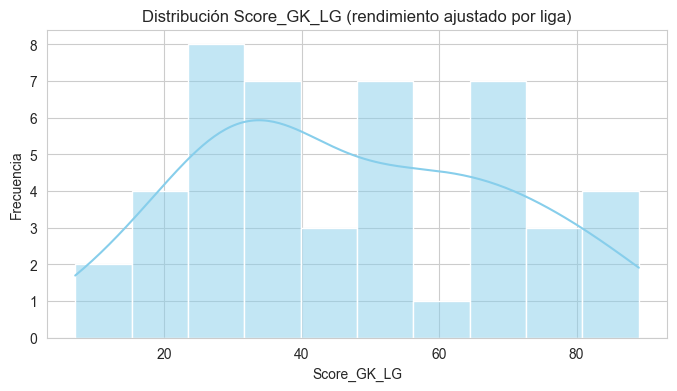

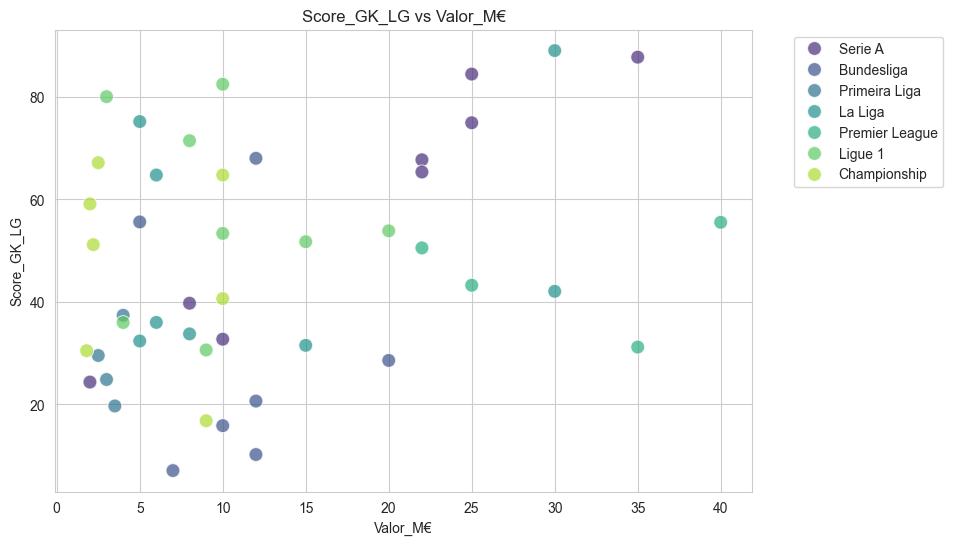

In [29]:
# =========================================================
# 2.1.5 — Validación visual (GK) 
# =========================================================

plot_hist(df_gk_final, "Score_GK_LG", bins=10, title="Distribución Score_GK_LG (rendimiento ajustado por liga)")

plot_scatter_value(
    df_gk_final,
    x_col="Valor_M€",
    y_col="Score_GK_LG",
    hue="League",
    title="Score_GK_LG vs Valor_M€"
)

### **2.1.6 Rendimiento vs eficiencia (Top 5)**

Sincronizamos las dos visiones del mercado (calidad pura vs rentabilidad) bajo el umbral de **8.0 M€.**


In [30]:
# =========================================================
# 2.1.6 — Comparativa rendimiento vs eficiencia (GK)
# =========================================================
top_score_gk, top_eff_gk = comparar_rankings(
    df_gk_final, 
    score_col="Score_GK_LG", 
    min_valor=8.0, 
    n=5)


- TOP 5 RENDIMIENTO (Score_GK_LG) [Filtro: >=8.0M€]


,Player,Age,Squad,League,Valor_M€,ShotStopping,CleanSheets,Score_GK_LG
410,Joan García,24,Barcelona,La Liga,30.0,97.826087,100.000000,89.052174
599,Mile Svilar,26,Roma,Serie A,35.0,97.826087,94.565217,87.771739
551,Marco Carnesecchi,25,Atalanta,Serie A,25.0,92.391304,80.434783,84.467391
722,Robin Risser,21,Lens,Ligue 1,10.0,91.304348,84.782609,82.486957
836,Vanja Milinković-Savić,29,Napoli,Serie A,25.0,80.434783,78.260870,74.967391



- TOP 5 EFICIENCIA (p_Efficiency) [Filtro: >=8.0M€]


,Player,Age,Squad,League,Valor_M€,Score_GK_LG,p_Efficiency,Score_Final
229,Dominik Greif,28,Lyon,Ligue 1,8.0,71.468478,73.913043,71.835163
722,Robin Risser,21,Lens,Ligue 1,10.0,82.486957,69.565217,80.548696
843,Viktor Johansson,27,Stoke City,Championship,10.0,64.766304,67.391304,65.160054
37,Alexander Nübel,29,Stuttgart,Bundesliga,12.0,68.034783,60.869565,66.960000
117,Berke Özer,25,Lille,Ligue 1,10.0,53.373913,56.521739,53.846087


### **2.1.7 Evaluación estratégica: oportunidad contractual (GK)**

Ranking para detectar porteros de nivel que están cerca de quedar libres, lo que permite negociar traspasos a la baja o pre-contratos.



In [31]:
# =========================================================
# 2.1.7 — Oportunidad contractual (GK)
# =========================================================
df_gk_final["Opportunity_Score"] = (
    df_gk_final["Score_GK_LG"] +
    np.where(df_gk_final["Finaliza_Contrato"] == "Sí", 15, 0)).clip(0, 100)

print("- Top 10 GK por oportunidad contractual:")
display(df_gk_final.sort_values("Opportunity_Score", ascending=False)[
    ["Player","Squad","League","Age","Valor_M€","Finaliza_Contrato","Score_GK_LG","Opportunity_Score"]].head(10))

- Top 10 GK por oportunidad contractual:


,Player,Squad,League,Age,Valor_M€,Finaliza_Contrato,Score_GK_LG,Opportunity_Score
410,Joan García,Barcelona,La Liga,24,30.0,No,89.052174,89.052174
599,Mile Svilar,Roma,Serie A,26,35.0,No,87.771739,87.771739
551,Marco Carnesecchi,Atalanta,Serie A,25,25.0,No,84.467391,84.467391
722,Robin Risser,Lens,Ligue 1,21,10.0,No,82.486957,82.486957
338,Hervé Koffi,Angers,Ligue 1,29,3.0,No,80.060870,80.060870
359,Ionuț Radu,Celta Vigo,La Liga,28,5.0,No,75.204348,75.204348
836,Vanja Milinković-Savić,Napoli,Serie A,29,25.0,No,74.967391,74.967391
229,Dominik Greif,Lyon,Ligue 1,28,8.0,No,71.468478,71.468478
37,Alexander Nübel,Stuttgart,Bundesliga,29,12.0,No,68.034783,68.034783
593,Michele Di Gregorio,Juventus,Serie A,28,22.0,No,67.739130,67.739130


### **2.1.8 Análisis Sub-21 (GK)**

Se evalúa el subconjunto de porteros ≤21 años dentro del universo modelado, identificando talento joven competitivo y su potencial valor estratégico a medio plazo.


In [32]:
# =========================================================
# 2.1.8 — Sub-21 GK
# =========================================================
df_gk_u21 = bloque_sub21(
    df_final=df_gk_final,
    age_col="Age",
    max_age_u21=21,
    score_col="Score_GK_LG",
    min_valor_u21=5.0, # Ajustamos a 5M para no ser tan restrictivos con porteros jóvenes
    n=5)


- TALENTO JOVEN SUB-21 (Mín. 5.0M€)


,Player,Squad,League,Age,Pos,Pie,Valor_M€,Finaliza_Contrato,Score_GK_LG,p_Efficiency,Score_Final
722,Robin Risser,Lens,Ligue 1,21,GK,Right,10.0,No,82.486957,69.565217,80.548696
327,Guillaume Restes,Toulouse,Ligue 1,20,GK,Left,20.0,No,53.879348,30.434783,50.362663
595,Mike Penders,Strasbourg,Ligue 1,20,GK,Right,15.0,No,51.756522,47.826087,51.166957
601,Mio Backhaus,Werder Bremen,Bundesliga,21,GK,Right,10.0,No,15.860870,15.217391,15.764348


### **2.1.9 Conclusión estratégica (GK)**

El modelo para porteros construye un universo elegible robusto y un Score_GK interpretable basado en percentiles comparables.  
La incorporación de eficiencia económica (Score_Final) permite equilibrar rendimiento y coste, identificando perfiles de élite, oportunidades de mercado y casos equilibrados rendimiento–precio.  

La capa de oportunidad contractual añade una priorización estratégica adicional para detectar posibles incorporaciones a bajo coste en fin de contrato.  
El análisis Sub-21 complementa la ingeniería de datos identificando porteros jóvenes con potencial competitivo y valor futuro.

## **2.2 Defensas (DF + híbridos)**

Para la línea defensiva en un sistema de tres centrales, buscamos jugadores con alta capacidad de interceptación y dominio del área. Se han aplicado filtros de perfil físico (altura ≥ 182cm) para asegurar la contundencia necesaria en duelos aéreos.


### **2.2.1 Universo elegible DF**

Se construye el universo de defensas elegibles incluyendo centrales puros y perfiles híbridos (DF,MF / MF,DF).
Se aplican filtros de edad, minutos mínimos y rango de valor de mercado para garantizar estabilidad estadística y coherencia económica antes del modelado.

In [33]:
# =========================================================
# 2.2.1 Universo DF (Centrales Estructurales)
# =========================================================
MIN_COL_DF = "Playing Time_Min"

# Filtro posicional: DF puro (evita híbridos de banda en este bloque)
df_df = build_universe(
    df_base=df_7,
    pos_pattern=r"^\s*DF\s*$",
    min_minutes_col=MIN_COL_DF,
    min_minutes=700,
    max_age=30,
    min_value=1.0,
    max_value=60.0,
    regex=True)

# Filtro de perfil físico: Altura mínima para asegurar dominio aéreo
ALTURA_MIN_CB = 182
df_df = df_df[df_df["Altura_cm"].fillna(0) >= ALTURA_MIN_CB].copy()

df_df = asegurar_contrato_label(df_df)
print(f"- Universo DF (Centrales) filtrado: {df_df.shape[0]} jugadores.")
display(df_df[["Player","Squad","League","Age","Altura_cm","Valor_M€"]].head(5))

- Universo DF (Centrales) filtrado: 116 jugadores.


,Player,Squad,League,Age,Altura_cm,Valor_M€
4,Abdelhamid Ait Boudlal,Rennes,Ligue 1,19,190.0,10.0
6,Abdukodir Khusanov,Manchester City,Premier League,22,186.0,40.0
16,Aitor Paredes,Athletic Club,La Liga,25,186.0,18.0
22,Albian Hajdari,Hoffenheim,Bundesliga,22,189.0,12.0
29,Alessandro Circati,Parma,Serie A,22,190.0,3.0


### **2.2.2 KPIs y normalización DF**

Se seleccionan las métricas de impacto defensivo directo: entradas ganadas (TklW) e intercepciones (Int). Estas variables definen la capacidad del central para abortar ataques rivales antes de que lleguen al área pequeña.

In [34]:
# =========================================================
# 2.2.2 KPIs DF + Normalización a percentiles
# =========================================================
K_TKLW = "Defense_Tackles_TklW"
K_INT  = "Defense_Int"
# Podríamos añadir Despejes (Defense_Clr) si el dataset lo permite
K_CLR  = "Defense_Clr"

kpis_df = [c for c in [K_TKLW, K_INT, K_CLR] if c in df_df.columns]

df_df_p = apply_percentiles(df_df, kpis=kpis_df)
print("- KPIs DF normalizados:", kpis_df)

- KPIs DF normalizados: ['Defense_Tackles_TklW', 'Defense_Int']


### **2.2.3 Construcción del Score_DF (rendimiento puro)**

Construimos el Score_DF como un índice de Impacto Defensivo. Si el dataset contiene despejes, se ponderan para medir la protección del área; de lo contrario, se basa en la agresividad en el corte.

In [35]:
# =========================================================
# 2.2.3 — Cálculo del Índice de Rendimiento (Score_DF)
# =========================================================

# Dimensiones: Robo e Intercepción (70%) y Despejes/Contundencia (30%)
impact_cols = [c for c in [f"p_{K_TKLW}", f"p_{K_INT}"] if c in df_df_p.columns]
df_df_p["Impact_Def"] = df_df_p[impact_cols].mean(axis=1) if len(impact_cols) else 50.0

if f"p_{K_CLR}" in df_df_p.columns:
    df_df_p["Score_DF"] = (0.70 * df_df_p["Impact_Def"] + 0.30 * df_df_p[f"p_{K_CLR}"])
else:
    df_df_p["Score_DF"] = df_df_p["Impact_Def"]

# Aplicamos League Factor para obtener el rendimiento real ajustado
df_df_p = apply_league_adjustment(df_df_p, "Score_DF", "League", "Score_DF_LG")

print("- Score_DF_LG calculado (Rendimiento ajustado por Liga):")
display(df_df_p.sort_values("Score_DF_LG", ascending=False)[
    ["Player","Squad","League","Age","Altura_cm","Valor_M€","Score_DF_LG"]].head(10))

- Score_DF_LG calculado (Rendimiento ajustado por Liga):


,Player,Squad,League,Age,Altura_cm,Valor_M€,Score_DF_LG
586,Maxence Lacroix,Crystal Palace,Premier League,25,190.0,35.0,95.474138
554,Marcos Senesi,Bournemouth,Premier League,28,185.0,22.0,94.612069
663,Oumar Solet,Udinese,Serie A,26,192.0,20.0,92.338362
532,Malang Sarr,Lens,Ligue 1,27,182.0,10.0,89.993534
202,David Affengruber,Elche,La Liga,24,185.0,9.0,88.918103
798,Tiago Gabriel,Lecce,Serie A,21,188.0,15.0,87.219828
183,Cristian Romero,Tottenham Hotspur,Premier League,27,185.0,60.0,85.991379
108,Ben Cabango,Swansea City,Championship,25,188.0,9.0,84.267241
372,Jacobo Ramón,Como,Serie A,21,187.0,18.0,83.534483
200,Danilho Doekhi,Union Berlin,Bundesliga,27,190.0,13.0,82.344828


### **2.2.4 Integración económica y Score_Final**

Integramos la eficiencia económica para identificar quién aporta más seguridad defensiva por cada millón de euros invertido.

In [36]:
# =========================================================
# 2.2.4 — Integración Score_Final (85% Deporte / 15% Economía)
# =========================================================
df_df_final = finalize_scores(
    df_df_p,
    score_col="Score_DF_LG", 
    w_score=0.85, 
    w_eff=0.15, 
    free_value_proxy=20.0)

# Generar Shortlist homogeneizada para el informe
short_df = format_shortlist(
    top_shortlist(df_df_final, n=10),
    score_col="Score_DF_LG",
    min_col=MIN_COL_DF,
    pos_label="DF",
    extra_cols=["Altura_cm"])

print("- SHORTLIST FINAL: DEFENSORES CENTRALES (Top 10 por Score_Final)")
display(short_df)

- SHORTLIST FINAL: DEFENSORES CENTRALES (Top 10 por Score_Final)


,Player,Squad,League,Age,Pos,Altura_cm,Valor_M€,Finaliza_Contrato,Score_DF_LG,Score_Final
0,Marcos Senesi,Bournemouth,Premier League,28,DF,185.0,22.0,Sí,94.612069,97.284483
1,Malang Sarr,Lens,Ligue 1,27,DF,182.0,10.0,Sí,89.993534,96.767241
2,Danilho Doekhi,Union Berlin,Bundesliga,27,DF,190.0,13.0,Sí,82.344828,96.250000
3,Ibrahima Konaté,Liverpool,Premier League,26,DF,194.0,50.0,Sí,70.689655,91.590517
4,Oumar Solet,Udinese,Serie A,26,DF,192.0,20.0,No,92.338362,90.384159
5,Maxence Lacroix,Crystal Palace,Premier League,25,DF,190.0,35.0,No,95.474138,90.334052
6,David Affengruber,Elche,La Liga,24,DF,185.0,9.0,No,88.918103,89.933836
7,Tiago Gabriel,Lecce,Serie A,21,DF,188.0,15.0,No,87.219828,87.326509
8,Ben Cabango,Swansea City,Championship,25,DF,188.0,9.0,No,84.267241,85.851293
9,Jacobo Ramón,Como,Serie A,21,DF,187.0,18.0,No,83.534483,83.030172


### **2.2.5 Validación visual**

Se analiza la distribución del Score_DF y su relación con el valor de mercado para comprobar dispersión adecuada, coherencia estructural y ausencia de concentraciones artificiales

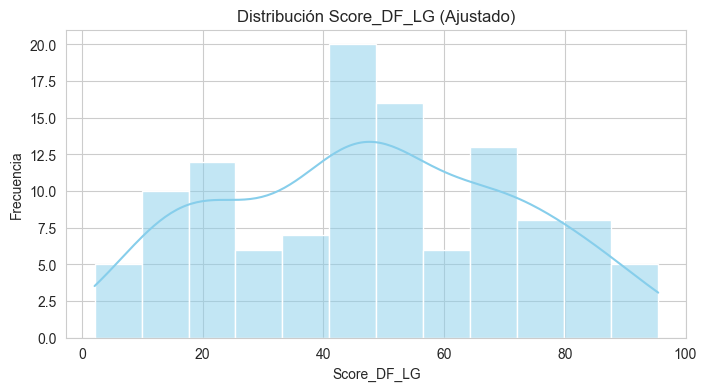

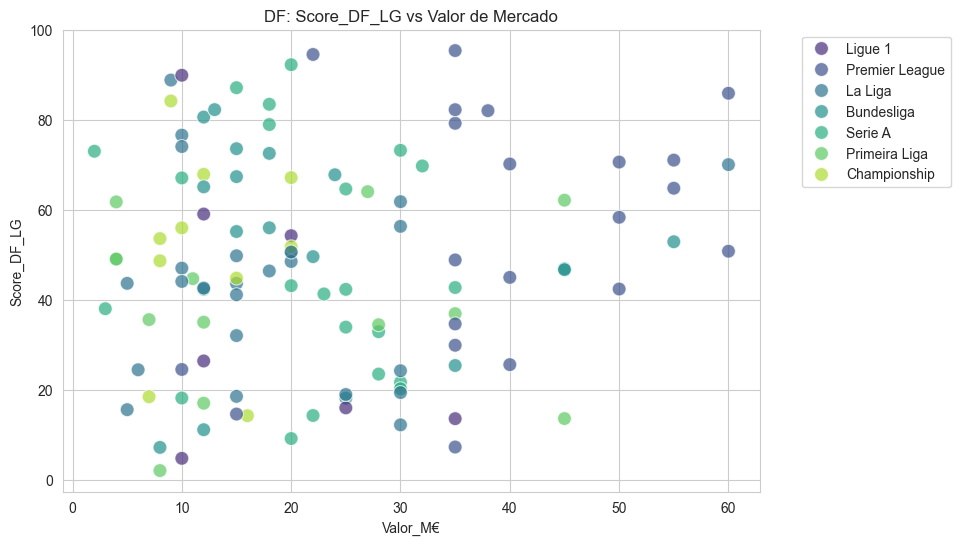

In [37]:
# 2.2.5 — Validación visual (DF)
# =========================================================
plot_hist(df_df_final, "Score_DF_LG", bins=12, title="Distribución Score_DF_LG (Ajustado)")

plot_scatter_value(
    df_df_final,
    x_col="Valor_M€",
    y_col="Score_DF_LG",
    hue="League",
    title="DF: Score_DF_LG vs Valor de Mercado")

### **2.2.6 Rendimiento vs eficiencia (Top 5)**

Sincronizamos las tablas de rendimiento puro y retorno de inversión bajo el filtro de élite (8.0 M€).

In [38]:
# =========================================================
# 2.2.6 — Comparativa rendimiento vs eficiencia (DF)
# =========================================================
top_score_df, top_eff_df = comparar_rankings(
    df_df_final, 
    score_col="Score_DF_LG", 
    min_valor=8.0, 
    n=5)


- TOP 5 RENDIMIENTO (Score_DF_LG) [Filtro: >=8.0M€]


,Player,Age,Squad,League,Valor_M€,Impact_Def,Score_DF_LG
586,Maxence Lacroix,25,Crystal Palace,Premier League,35.0,95.474138,95.474138
554,Marcos Senesi,28,Bournemouth,Premier League,22.0,94.612069,94.612069
663,Oumar Solet,26,Udinese,Serie A,20.0,97.198276,92.338362
532,Malang Sarr,27,Lens,Ligue 1,10.0,96.767241,89.993534
202,David Affengruber,24,Elche,La Liga,9.0,90.732759,88.918103



- TOP 5 EFICIENCIA (p_Efficiency) [Filtro: >=8.0M€]


,Player,Age,Squad,League,Valor_M€,Score_DF_LG,p_Efficiency,Score_Final
202,David Affengruber,24,Elche,La Liga,9.0,88.918103,95.689655,89.933836
108,Ben Cabango,25,Swansea City,Championship,9.0,84.267241,94.827586,85.851293
760,Santiago Mouriño,24,Villarreal,La Liga,10.0,76.668103,93.103448,79.133405
772,Sergi Cardona,26,Villarreal,La Liga,10.0,74.133621,92.241379,76.849784
22,Albian Hajdari,22,Hoffenheim,Bundesliga,12.0,80.689655,91.379310,82.293103


### **2.2.7 Evaluación estratégica: oportunidad contractual**

Identificamos centrales que finalizan contrato, una prioridad para la gestión de activos en una defensa de tres donde la rotación es clave.


In [39]:
# =========================================================
# 2.2.7 — Oportunidad contractual (DF)
# =========================================================
df_df_final["Opportunity_Score"] = (
    df_df_final["Score_DF_LG"] +
    np.where(df_df_final["Finaliza_Contrato"] == "Sí", 15, 0)).clip(0, 100)

print("- Top 10 DF por oportunidad contractual:")
display(df_df_final.sort_values("Opportunity_Score", ascending=False)[
    ["Player","Squad","League","Age","Valor_M€","Finaliza_Contrato","Score_DF_LG","Opportunity_Score"]].head(10))

- Top 10 DF por oportunidad contractual:


,Player,Squad,League,Age,Valor_M€,Finaliza_Contrato,Score_DF_LG,Opportunity_Score
532,Malang Sarr,Lens,Ligue 1,27,10.0,Sí,89.993534,100.000000
554,Marcos Senesi,Bournemouth,Premier League,28,22.0,Sí,94.612069,100.000000
200,Danilho Doekhi,Union Berlin,Bundesliga,27,13.0,Sí,82.344828,97.344828
586,Maxence Lacroix,Crystal Palace,Premier League,25,35.0,No,95.474138,95.474138
663,Oumar Solet,Udinese,Serie A,26,20.0,No,92.338362,92.338362
202,David Affengruber,Elche,La Liga,24,9.0,No,88.918103,88.918103
798,Tiago Gabriel,Lecce,Serie A,21,15.0,No,87.219828,87.219828
183,Cristian Romero,Tottenham Hotspur,Premier League,27,60.0,No,85.991379,85.991379
351,Ibrahima Konaté,Liverpool,Premier League,26,50.0,Sí,70.689655,85.689655
108,Ben Cabango,Swansea City,Championship,25,9.0,No,84.267241,84.267241


### **2.2.8 Análisis Sub-21 (DF)**

Detección de centrales jóvenes con físico y métricas de élite.

In [40]:
# =========================================================
# 2.2.8 — Sub-21 DF
# =========================================================
df_df_u21 = bloque_sub21(
    df_final=df_df_final,
    age_col="Age",
    max_age_u21=21,
    score_col="Score_DF_LG",
    min_valor_u21=5.0,
    n=5)


- TALENTO JOVEN SUB-21 (Mín. 5.0M€)


,Player,Squad,League,Age,Pos,Pie,Valor_M€,Finaliza_Contrato,Score_DF_LG,p_Efficiency,Score_Final
798,Tiago Gabriel,Lecce,Serie A,21,DF,Right,15.0,No,87.219828,87.931034,87.326509
372,Jacobo Ramón,Como,Serie A,21,DF,Right,18.0,No,83.534483,80.172414,83.030172
892,Álex Valle,Como,Serie A,21,DF,Left,10.0,No,67.155172,90.517241,70.659483
847,Vitor Reis,Girona,La Liga,20,DF,Right,30.0,No,61.883621,43.103448,59.066595
752,Samson Baidoo,Lens,Ligue 1,21,DF,Right,12.0,No,59.127155,83.620690,62.801185


### **2.2.9 Conclusión estratégica (DF)**

El modelo para la línea defensiva ha priorizado la contundencia física y estadística. Gracias al ajuste por liga, centralizadores de ligas como la Championship o la Primeira Liga son evaluados en su justa medida frente a los de las "Big Five". La sincronización en 8.0 M€ permite al analista descartar jugadores de complemento y centrarse en perfiles que pueden liderar una defensa de tres en un contexto de máxima exigencia.

## **2.3 Carrileros (WB)**

El modelo para carrileros busca identificar especialistas de banda con alta capacidad de progresión y precisión en el envío al área. Se priorizan jugadores con un perfil de "ida y vuelta", capaces de sostener el bloque defensivo sin renunciar a la generación de ventajas en el último tercio.



### **2.3.1 Universo elegible (Carrileros)**

Construimos el universo combinando perfiles defensivos e híbridos (DF,MF). Aplicamos un filtro táctico obligatorio basado en el volumen de centros y regates para distinguir al carrilero moderno del lateral posicional clásico.



In [41]:
# =========================================================
# 2.3.1 — Universo elegible (Carrileros)
# =========================================================

# --- Función Auxiliar (Escudo contra errores de definición) ---
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

MIN_COL_WB = "Playing Time_Min"

# Universo amplio: incluye perfiles de banda (DF, MF y sus híbridos)
POS_WB_AMPLIO = r"DF|DF,MF|MF,DF|MF"
df_wb_base = build_universe(
    df_base=df_7,
    pos_pattern=POS_WB_AMPLIO,
    min_minutes_col=MIN_COL_WB,
    min_minutes=700,
    max_age=30,
    min_value=1.0,
    max_value=60.0,
    regex=True)

# --- EXCLUSIÓN SIMPLE: fuera FW (ej: "MF,FW", "FW", "DF,FW") ---
df_wb_base = df_wb_base[~df_wb_base["Pos"].astype(str).str.contains(r"\bFW\b", regex=True, na=False)].copy()

# --- Filtro Táctico de Banda (Behavioral Scouting) ---
mins_wb = df_wb_base[MIN_COL_WB].replace(0, 90)

# Buscamos columnas de centros y regates
COL_CRS = pick_col(df_wb_base, ["PassTypes_Pass Types_Crs", "Misc_Performance_Crs", "Crosses"])
COL_DRB = pick_col(df_wb_base, ["Possession_Take-Ons_Att", "Dribbles_Att"])

if COL_CRS and COL_DRB:
    # Calculamos centros por 90 min
    df_wb_base["Crs_90"] = (df_wb_base[COL_CRS].fillna(0) / mins_wb) * 90
    # Exigimos actividad mínima en banda (centros o intentos de desequilibrio)
    df_wb = df_wb_base[
        (df_wb_base["Crs_90"] >= 1.5) |
        (df_wb_base[COL_DRB].fillna(0) >= 15)
    ].copy()
else:
    df_wb = df_wb_base.copy()

df_wb = asegurar_contrato_label(df_wb)
print(f"- Universo Carrileros (WB) consolidado: {df_wb.shape[0]} jugadores.")
display(df_wb[["Player","Squad","League","Age","Pos","Valor_M€"]].head(5))

- Universo Carrileros (WB) consolidado: 363 jugadores.


,Player,Squad,League,Age,Pos,Valor_M€
2,Aaron Zehnter,Wolfsburg,Bundesliga,21,DF,6.0
4,Abdelhamid Ait Boudlal,Rennes,Ligue 1,19,DF,10.0
5,Abdoul Ouattara,Strasbourg,Ligue 1,20,"MF,DF",9.0
6,Abdukodir Khusanov,Manchester City,Premier League,22,DF,40.0
9,Adam Daghim,Wolfsburg,Bundesliga,20,MF,7.5


### **2.3.2 KPIs y normalización (WB)**

Seleccionamos métricas que cubren las tres dimensiones del rol: Motor/Progresión (conducciones), Producción Ofensiva (centros y pases clave) y Defensa (tackles).


In [42]:
# =========================================================
# 2.3.2 KPIs WB + Normalización a percentiles
# =========================================================
K_TKL = "Defense_Tackles_TklW"
K_INT = "Defense_Int"
K_CRS = "PassTypes_Pass Types_Crs"
K_GA  = "Per 90 Minutes_G+A"

kpis_wb = [c for c in [K_TKL, K_INT, K_CRS, K_GA] if c in df_wb.columns]

df_wb_p = apply_percentiles(df_wb, kpis=kpis_wb)
print("- KPIs WB normalizados:", kpis_wb)

- KPIs WB normalizados: ['Defense_Tackles_TklW', 'Defense_Int', 'PassTypes_Pass Types_Crs', 'Per 90 Minutes_G+A']


### **2.3.3 Construcción del Score_WB (rendimiento puro)**

El Score_WB pondera el equilibrio entre las tareas defensivas y la influencia en el ataque.


In [43]:
# =========================================================
# 2.3.3 Cálculo del Índice de Rendimiento (Score_WB)
# =========================================================
df_wb_p["Motor_Off"] = df_wb_p[[f"p_{K_CRS}", f"p_{K_GA}"]].mean(axis=1) if K_CRS in df_wb_p.columns else 50.0
df_wb_p["Defense"]   = df_wb_p[[f"p_{K_TKL}", f"p_{K_INT}"]].mean(axis=1) if K_TKL in df_wb_p.columns else 50.0

W_OFF = 0.60
W_DEF = 0.40

df_wb_p["Score_WB"] = (W_OFF * df_wb_p["Motor_Off"] + W_DEF * df_wb_p["Defense"]).clip(0, 100)

df_wb_p = apply_league_adjustment(df_wb_p, "Score_WB", "League", "Score_WB_LG")

print("- Score_WB_LG calculado (Rendimiento ajustado):")
display(df_wb_p.sort_values("Score_WB_LG", ascending=False)[
    ["Player","Squad","League","Age","Pos","Pie","Valor_M€","Score_WB_LG"]].head(10))

- Score_WB_LG calculado (Rendimiento ajustado):


,Player,Squad,League,Age,Pos,Pie,Valor_M€,Score_WB_LG
708,Reece James,Chelsea,Premier League,26,"DF,MF",Right,50.0,88.471074
205,David Raum,RB Leipzig,Bundesliga,27,DF,Left,20.0,86.664463
274,Federico Dimarco,Inter,Serie A,28,MF,Left,50.0,85.526171
148,Carlos Romero,Espanyol,La Liga,24,DF,Left,15.0,83.799449
251,Elliot Anderson,Nottingham Forest,Premier League,23,MF,Right,60.0,82.355372
567,Mateus Fernandes,West Ham United,Premier League,21,MF,Right,32.0,80.853994
673,Patrick Dorgu,Manchester Utd,Premier League,21,MF,Left,30.0,77.410468
570,Matheus Nunes,Manchester City,Premier League,27,DF,Right,38.0,77.066116
862,Wouter Burger,Hoffenheim,Bundesliga,25,MF,Left,9.0,75.847934
427,Jordan Holsgrove,Estoril,Primeira Liga,26,MF,Left,3.5,75.393939


### **2.3.4 Integración económica + Score_Final**

Buscamos maximizar la calidad en banda minimizando el coste de adquisición.


In [44]:
# =========================================================
# 2.3.4 Integración Score_Final (85% Deporte / 15% Economía)
# =========================================================
df_wb_final = finalize_scores(
    df_wb_p,
    score_col="Score_WB_LG", 
    w_score=0.85, 
    w_eff=0.15, 
    free_value_proxy=12.0)

# Generar Shortlist
short_wb = format_shortlist(
    top_shortlist(df_wb_final, n=10),
    score_col="Score_WB_LG",
    min_col=MIN_COL_WB,
    pos_label="WB",
    extra_cols=["Pie"])

print("- SHORTLIST FINAL: CARRILEROS (Top 10 por Score_Final)")
display(short_wb)

- SHORTLIST FINAL: CARRILEROS (Top 10 por Score_Final)


,Player,Squad,League,Age,Pos,Pie,Valor_M€,Finaliza_Contrato,Score_WB_LG,Score_Final
0,Harry Wilson,Fulham,Premier League,28,MF,Left,20.0,Sí,69.917355,93.288017
1,Marcos Senesi,Bournemouth,Premier League,28,DF,Left,22.0,Sí,67.245179,89.973760
2,Ryan Sessegnon,Fulham,Premier League,25,"DF,MF",Left,20.0,Sí,65.426997,87.680785
3,David Raum,RB Leipzig,Bundesliga,27,DF,Left,20.0,No,86.664463,84.739174
4,Carlos Romero,Espanyol,La Liga,24,DF,Left,15.0,No,83.799449,83.998127
5,Zeki Çelik,Roma,Serie A,29,"MF,DF",Right,12.0,Sí,60.284435,81.201183
6,Reece James,Chelsea,Premier League,26,"DF,MF",Right,50.0,No,88.471074,80.572314
7,Tommy Doyle,Birmingham City,Championship,24,MF,Right,8.0,Sí,59.780992,80.540837
8,Weston McKennie,Juventus,Serie A,27,MF,Right,22.0,Sí,59.499311,80.176286
9,Jordan Holsgrove,Estoril,Primeira Liga,26,MF,Left,3.5,No,75.393939,78.960882


### **2.3.5 Validación visual**

Se analiza:

- Distribución del Score_WB
- Relación rendimiento vs valor de mercado

Permite verificar dispersión y coherencia estructural.


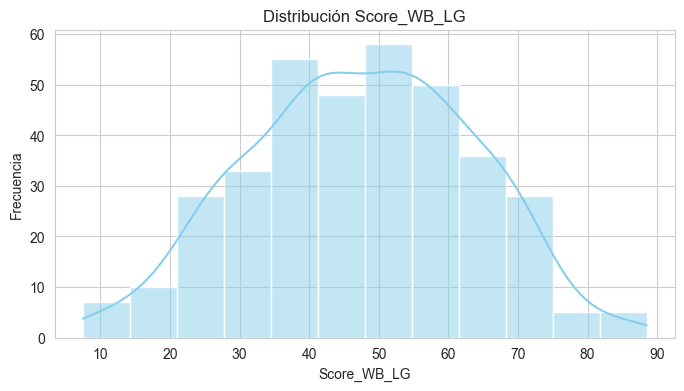

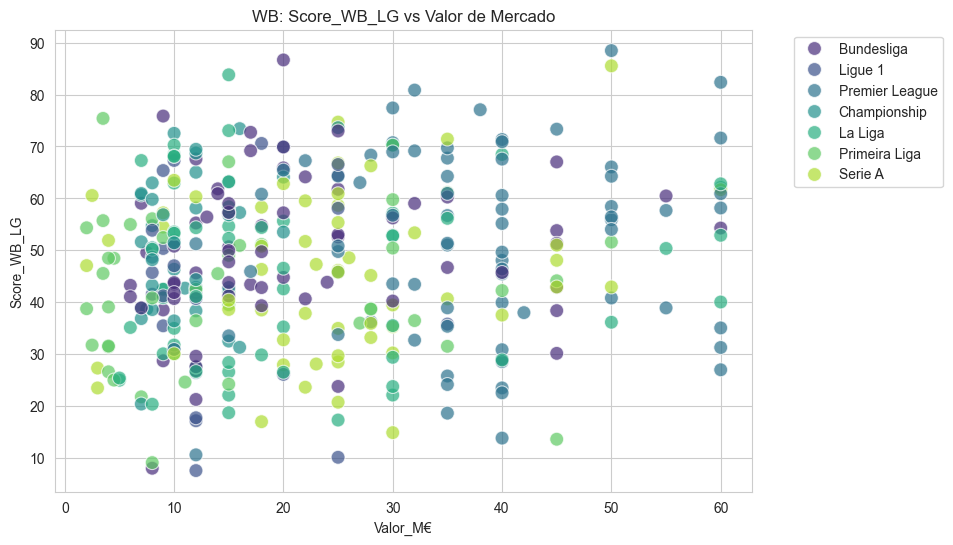

In [45]:
# =========================================================
# 2.3.5 Validación visual (WB)
# =========================================================
plot_hist(df_wb_final, "Score_WB_LG", bins=12, title="Distribución Score_WB_LG")

plot_scatter_value(
    df_wb_final,
    x_col="Valor_M€",
    y_col="Score_WB_LG",
    hue="League",
    title="WB: Score_WB_LG vs Valor de Mercado")

### **2.3.6 Comparativa rendimiento vs eficiencia**

Sincronización total bajo el filtro de élite **(8.0 M€).**


In [46]:
# =========================================================
# 2.3.6 Comparativa rendimiento vs eficiencia (WB)
# =========================================================
top_score_wb, top_eff_wb = comparar_rankings(
    df_wb_final, 
    score_col="Score_WB_LG", 
    min_valor=8.0, 
    n=5)


- TOP 5 RENDIMIENTO (Score_WB_LG) [Filtro: >=8.0M€]


,Player,Age,Squad,League,Valor_M€,Score_WB_LG
708,Reece James,26,Chelsea,Premier League,50.0,88.471074
205,David Raum,27,RB Leipzig,Bundesliga,20.0,86.664463
274,Federico Dimarco,28,Inter,Serie A,50.0,85.526171
148,Carlos Romero,24,Espanyol,La Liga,15.0,83.799449
251,Elliot Anderson,23,Nottingham Forest,Premier League,60.0,82.355372



- TOP 5 EFICIENCIA (p_Efficiency) [Filtro: >=8.0M€]


,Player,Age,Squad,League,Valor_M€,Score_WB_LG,p_Efficiency,Score_Final
862,Wouter Burger,25,Hoffenheim,Bundesliga,9.0,75.847934,95.041322,78.726942
428,Jordan James,21,Leicester City,Championship,8.0,62.965565,94.490358,67.694284
464,Kassoum Ouattara,21,Monaco,Ligue 1,9.0,65.343388,93.388430,69.550145
765,Scott Twine,26,Bristol City,Championship,10.0,72.519284,93.112948,75.608333
772,Sergi Cardona,26,Villarreal,La Liga,10.0,70.233333,92.561983,73.582631


### **2.3.7 Evaluación estratégica: oportunidad contractual (WB)**

Se construye un ranking específico para carrileros en fin de contrato aplicando un bonus estratégico fijo.
Este bloque prioriza oportunidades de mercado sin alterar el Score_Final.


In [47]:
# =========================================================
# 2.3.7 Oportunidad contractual (WB)
# =========================================================
df_wb_final["Opportunity_Score"] = (
    df_wb_final["Score_WB_LG"] +
    np.where(df_wb_final["Finaliza_Contrato"] == "Sí", 15, 0)).clip(0, 100)

print("- Top 10 WB por oportunidad contractual:")
display(df_wb_final.sort_values("Opportunity_Score", ascending=False)[
    ["Player","Squad","League","Age","Valor_M€","Pie","Finaliza_Contrato","Score_WB_LG","Opportunity_Score"]].head(10))

- Top 10 WB por oportunidad contractual:


,Player,Squad,League,Age,Valor_M€,Pie,Finaliza_Contrato,Score_WB_LG,Opportunity_Score
708,Reece James,Chelsea,Premier League,26,50.0,Right,No,88.471074,88.471074
205,David Raum,RB Leipzig,Bundesliga,27,20.0,Left,No,86.664463,86.664463
274,Federico Dimarco,Inter,Serie A,28,50.0,Left,No,85.526171,85.526171
334,Harry Wilson,Fulham,Premier League,28,20.0,Left,Sí,69.917355,84.917355
148,Carlos Romero,Espanyol,La Liga,24,15.0,Left,No,83.799449,83.799449
251,Elliot Anderson,Nottingham Forest,Premier League,23,60.0,Right,No,82.355372,82.355372
554,Marcos Senesi,Bournemouth,Premier League,28,22.0,Left,Sí,67.245179,82.245179
567,Mateus Fernandes,West Ham United,Premier League,21,32.0,Right,No,80.853994,80.853994
744,Ryan Sessegnon,Fulham,Premier League,25,20.0,Left,Sí,65.426997,80.426997
673,Patrick Dorgu,Manchester Utd,Premier League,21,30.0,Left,No,77.410468,77.410468


### **2.3.8 Análisis Sub-21**

Se analiza el subconjunto de carrileros ≤21 dentro del universo ya modelado para detectar talento joven competitivo.

In [48]:
# =========================================================
# 2.3.8 Sub-21 WB
# =========================================================
df_wb_u21 = bloque_sub21(
    df_final=df_wb_final,
    age_col="Age",
    max_age_u21=21,
    score_col="Score_WB_LG",
    min_valor_u21=5.0,
    n=5)


- TALENTO JOVEN SUB-21 (Mín. 5.0M€)


,Player,Squad,League,Age,Pos,Pie,Valor_M€,Finaliza_Contrato,Score_WB_LG,p_Efficiency,Score_Final
567,Mateus Fernandes,West Ham United,Premier League,21,MF,Right,32.0,No,80.853994,50.413223,76.287879
673,Patrick Dorgu,Manchester Utd,Premier League,21,MF,Left,30.0,No,77.410468,52.341598,73.650138
631,Nico O’Reilly,Manchester City,Premier League,20,"DF,MF",Left,40.0,No,71.322314,36.363636,66.078512
871,Yankuba Minteh,Brighton,Premier League,21,MF,Left,40.0,No,70.895317,36.088154,65.674242
220,Diego Moreira,Strasbourg,Ligue 1,21,MF,Left,18.0,No,70.569835,70.523416,70.562872


### **2.3.9 Conclusión estratégica (WB)**

El modelo para carrileros ha logrado aislar perfiles que no solo defienden, sino que son motores ofensivos. El uso del League Factor ha sido crítico aquí, ya que la exigencia física para un carrilero en la Premier League o Bundesliga es superior. Con el filtro de 8.0 M€, la lista definitiva ofrece jugadores con capacidad de impacto inmediato, mientras que el análisis Sub-21 revela talentos con una proyección de valor de mercado muy atractiva.


## **2.4 Mediocentros (MC)**

En un sistema de tres centrales y carrileros largos, el doble pivote debe ser el motor del equipo. Este modelo busca el equilibrio entre un perfil destructor (recuperación de posesión) y un perfil creador (distribución y llegada). Aplicamos Behavioral Scouting para asegurar que los jugadores seleccionados actúan realmente en el centro del campo y no en los costados o en la mediapunta.

### **2.4.1 Universo elegible (Mediocentros)**

Construimos el universo MF filtrando por comportamiento. Un mediocentro real no debería promediar un volumen excesivo de centros (extremos) ni de tiros a puerta (delanteros/mediapuntas).

In [49]:
# =========================================================
# 2.4.1 Universo MF - FILTRO DE COMPORTAMIENTO
# =========================================================

# --- Función Auxiliar (SOLUCIÓN AL ERROR pick_col) ---
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

MIN_COL_MF = "Playing Time_Min"

# 1. Filtro Posicional Básico: Tiene que tener "MF" pero NO "FW"
df_base_mf = df_7[
    (df_7["Pos"].astype(str).str.contains("MF", na=False)) & 
    (~df_7["Pos"].astype(str).str.contains("FW", na=False))
].copy()

df_mf_temp = build_universe(
    df_base=df_base_mf,
    pos_pattern="MF", 
    min_minutes_col=MIN_COL_MF,
    min_minutes=700,
    max_age=30,
    min_value=1.0,
    max_value=80.0,
    regex=False)

# 2. ESCUDO TÁCTICO (Behavioral Scouting por 90 minutos)
mins_mc = df_mf_temp[MIN_COL_MF].replace(0, 90)

# A) Anti-Bandas: Máximo 2.5 centros por 90 min
COL_CRS = pick_col(df_mf_temp, ["Misc_Performance_Crs", "PassTypes_Pass Types_Crs", "Crosses"])
if COL_CRS:
    df_mf_temp["Crs_90"] = (df_mf_temp[COL_CRS].fillna(0) / mins_mc) * 90
    df_mf_temp = df_mf_temp[df_mf_temp["Crs_90"] <= 2.5]

# B) Anti-Mediapuntas: Máximo 1.8 tiros por 90 min
COL_SH = pick_col(df_mf_temp, ["Shooting_Standard_Sh/90", "Shooting_Standard_Sh"])
if COL_SH:
    sh_val = df_mf_temp[COL_SH].fillna(0)
    if "90" not in str(COL_SH):
        sh_val = (sh_val / mins_mc) * 90
    df_mf_temp["Sh_90"] = sh_val
    df_mf_temp = df_mf_temp[df_mf_temp["Sh_90"] <= 1.8]

df_mf = df_mf_temp.copy()
print(f"- Universo MC consolidado (Pivotes e Interiores): {df_mf.shape[0]} jugadores.")
display(df_mf[["Player","Squad","League","Age","Pos","Valor_M€"]].head(5))

- Universo MC consolidado (Pivotes e Interiores): 112 jugadores.

,Player,Squad,League,Age,Pos,Valor_M€
5,Abdoul Ouattara,Strasbourg,Ligue 1,20,"MF,DF",9.0
9,Adam Daghim,Wolfsburg,Bundesliga,20,MF,7.5
14,Aidan Morris,Middlesbrough,Championship,24,MF,7.0
19,Alan Varela,Porto,Primeira Liga,24,MF,32.0
27,Aleksandar Pavlovic,Bayern Munich,Bundesliga,21,MF,65.0


### **2.4.2 KPIs y normalización (percentiles 0–100)**

Buscamos el equilibrio: capacidad de robo y capacidad de generar peligro

In [50]:
# =========================================================
# 2.4.2 KPIs MC + Normalización a percentiles
# =========================================================
# DESTRUCCIÓN
K_TKLW = pick_col(df_mf, ["Defense_Tackles_TklW", "Misc_Performance_TklW"])
K_INT  = pick_col(df_mf, ["Defense_Int", "Misc_Performance_Int"])

# CREACIÓN / LLEGADA
K_GA   = pick_col(df_mf, ["Per 90 Minutes_G+A", "Performance_G+A"])
K_AST  = pick_col(df_mf, ["Per 90 Minutes_Ast", "Performance_Ast"])

# SEGURIDAD (Invertido: menos faltas es mejor)
K_FLS  = pick_col(df_mf, ["Misc_Performance_Fls", "Fls"])

kpis_mf = [c for c in [K_TKLW, K_INT, K_GA, K_AST, K_FLS] if c is not None]
lower_mf = {K_FLS} if K_FLS else set()

df_mf_p = apply_percentiles(df_mf, kpis=kpis_mf, lower_is_better=lower_mf)
print("- KPIs MF detectados y normalizados:", kpis_mf)

- KPIs MF detectados y normalizados: ['Defense_Tackles_TklW', 'Defense_Int', 'Per 90 Minutes_G+A', 'Per 90 Minutes_Ast', 'Misc_Performance_Fls']


### **2.4.3 Construcción del Score_MC (rendimiento puro)**

El modelo otorga un peso dominante a la destrucción (60%) para asegurar un pivote sólido, pero premia la llegada (40%).

In [51]:
# =========================================================
# 2.4.3 Cálculo del Índice de Rendimiento (Score_MC)
# =========================================================
# Destroyer_Index: Media de Tackles e Intercepciones
dest_cols = [f"p_{c}" for c in [K_TKLW, K_INT] if c and f"p_{c}" in df_mf_p.columns]
df_mf_p["Destroyer_Index"] = df_mf_p[dest_cols].mean(axis=1) if dest_cols else 50.0

# Creator_Index: Media de Goles y Asistencias
creat_cols = [f"p_{c}" for c in [K_GA, K_AST] if c and f"p_{c}" in df_mf_p.columns]
df_mf_p["Creator_Index"] = df_mf_p[creat_cols].mean(axis=1) if creat_cols else 50.0

W_DEST = 0.60
W_CREA = 0.40

df_mf_p["Score_MC"] = (W_DEST * df_mf_p["Destroyer_Index"] + W_CREA * df_mf_p["Creator_Index"]).clip(0, 100)

# Aplicamos League Factor
df_mf_p = apply_league_adjustment(df_mf_p, "Score_MC", "League", "Score_MC_LG")

print("- Score_MC_LG calculado (Top 10 Rendimiento Puro):")
display(df_mf_p.sort_values("Score_MC_LG", ascending=False)[
    ["Player","Pos","Squad","League","Age","Valor_M€","Destroyer_Index","Creator_Index","Score_MC_LG"]].head(10))

- Score_MC_LG calculado (Top 10 Rendimiento Puro):


,Player,Pos,Squad,League,Age,Valor_M€,Destroyer_Index,Creator_Index,Score_MC_LG
567,Mateus Fernandes,MF,West Ham United,Premier League,21,32.0,92.410714,69.196429,83.125000
419,Jon Gorrotxategi,MF,Real Sociedad,La Liga,24,15.0,80.133929,65.625000,72.843750
563,Martín Zubimendi,MF,Arsenal,Premier League,27,75.0,87.946429,50.000000,72.767857
631,Nico O’Reilly,"DF,MF",Manchester City,Premier League,20,40.0,66.517857,77.232143,70.803571
802,Tim Iroegbunam,MF,Everton,Premier League,22,12.0,71.875000,68.080357,70.357143
536,Malo Gusto,"DF,MF",Chelsea,Premier League,22,35.0,65.401786,77.455357,70.223214
617,Máximo Perrone,MF,Como,Serie A,23,25.0,69.866071,79.241071,69.935268
357,Iliman Ndiaye,MF,Everton,Premier League,25,45.0,61.160714,82.366071,69.642857
74,Antonio Blanco,MF,Alavés,La Liga,25,10.0,94.196429,35.714286,69.387500
788,Sydie Peck,MF,Sheffield United,Championship,21,12.0,87.500000,69.866071,68.379464


### **2.4.4 Integración económica + Score_Final (MC)**



In [52]:
# =========================================================
# 2.4.4 — Integración Score_Final (85% Deporte / 15% Economía)
# =========================================================
df_mf_final = finalize_scores(
    df_mf_p,
    score_col="Score_MC_LG", 
    w_score=0.85, 
    w_eff=0.15, 
    free_value_proxy=15.0)

# Generar Shortlist
short_mc = format_shortlist(
    top_shortlist(df_mf_final, n=10),
    score_col="Score_MC_LG",
    min_col=MIN_COL_MF,
    pos_label="MC")

print("- SHORTLIST FINAL: MEDIOCENTROS (Top 10 por Score_Final)")
display(short_mc)

- SHORTLIST FINAL: MEDIOCENTROS (Top 10 por Score_Final)


,Player,Squad,League,Age,Pos,Valor_M€,Finaliza_Contrato,Score_MC_LG,Score_Final
0,Weston McKennie,Juventus,Serie A,27,MF,22.0,Sí,60.138393,80.124877
1,Mateus Fernandes,West Ham United,Premier League,21,MF,32.0,No,83.125000,79.227679
2,Ryan Sessegnon,Fulham,Premier League,25,"DF,MF",20.0,Sí,57.991071,77.259040
3,Jon Gorrotxategi,Real Sociedad,La Liga,24,MF,15.0,No,72.843750,73.836830
4,Tim Iroegbunam,Everton,Premier League,22,MF,12.0,No,70.357143,72.794643
5,Antonio Blanco,Alavés,La Liga,25,MF,10.0,No,69.387500,72.774018
6,Sydie Peck,Sheffield United,Championship,21,MF,12.0,No,68.379464,70.979687
7,Máximo Perrone,Como,Serie A,23,MF,25.0,No,69.935268,68.552121
8,Nicolas Seiwald,RB Leipzig,Bundesliga,24,MF,18.0,No,68.185714,68.404286
9,Taichi Fukui,Arouca,Primeira Liga,21,MF,2.0,No,60.892857,66.758929


### **2.4.5 Validación visual**

Se analiza:

- Distribución del Score_MF
- Relación rendimiento vs valor de mercado

Permite verificar dispersión y coherencia estructural.

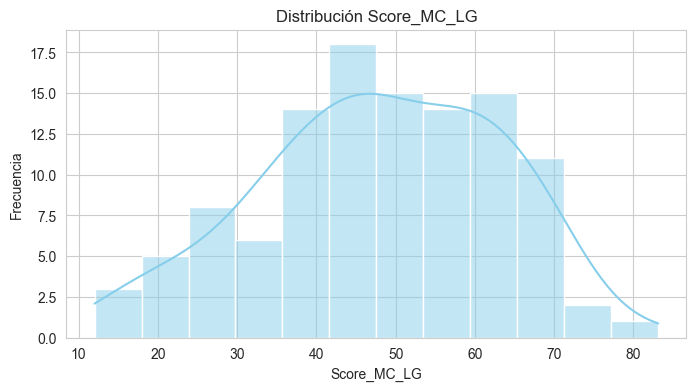

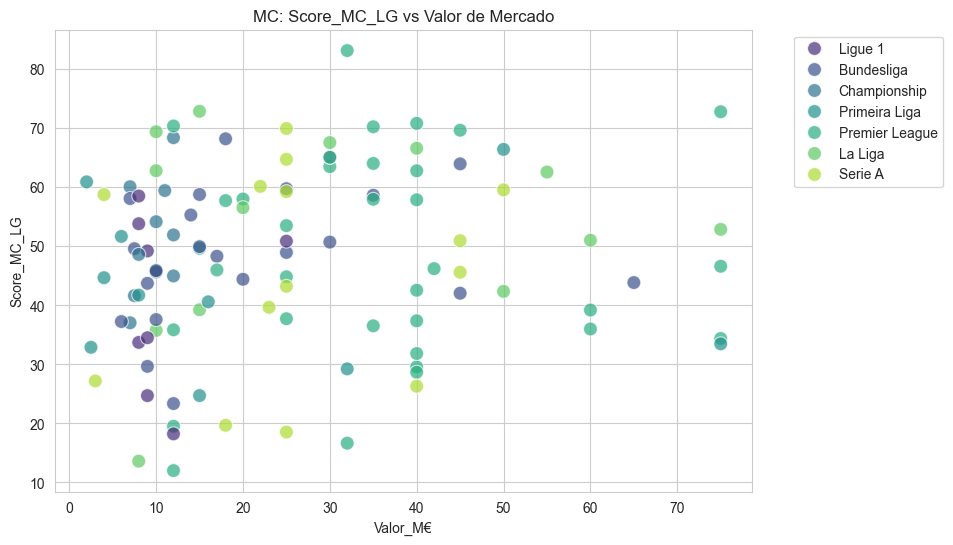

In [53]:
# =========================================================
# 2.4.5 Validación visual (MC)
# =========================================================
plot_hist(df_mf_final, "Score_MC_LG", bins=12, title="Distribución Score_MC_LG")

plot_scatter_value(
    df_mf_final,
    x_col="Valor_M€",
    y_col="Score_MC_LG",
    hue="League",
    title="MC: Score_MC_LG vs Valor de Mercado")

### **2.4.6 Comparativa rendimiento vs eficiencia**

Se comparan:

- Top 5 por Score_WB (rendimiento puro)
- Top 5 por p_Efficiency (retorno económico)

Permite diferenciar élite deportiva y oportunidades de mercado.

In [54]:
# =========================================================
# 2.4.6 Comparativa rendimiento vs eficiencia (MC)
# =========================================================
top_score_mc, top_eff_mc = comparar_rankings(
    df_mf_final, 
    score_col="Score_MC_LG", 
    min_valor=8.0, 
    n=5)


- TOP 5 RENDIMIENTO (Score_MC_LG) [Filtro: >=8.0M€]


,Player,Age,Squad,League,Valor_M€,Destroyer_Index,Creator_Index,Score_MC_LG
567,Mateus Fernandes,21,West Ham United,Premier League,32.0,92.410714,69.196429,83.125000
419,Jon Gorrotxategi,24,Real Sociedad,La Liga,15.0,80.133929,65.625000,72.843750
563,Martín Zubimendi,27,Arsenal,Premier League,75.0,87.946429,50.000000,72.767857
631,Nico O’Reilly,20,Manchester City,Premier League,40.0,66.517857,77.232143,70.803571
802,Tim Iroegbunam,22,Everton,Premier League,12.0,71.875000,68.080357,70.357143



- TOP 5 EFICIENCIA (p_Efficiency) [Filtro: >=8.0M€]


,Player,Age,Squad,League,Valor_M€,Score_MC_LG,p_Efficiency,Score_Final
537,Mamadou Coulibaly,21,Monaco,Ligue 1,8.0,58.498661,92.857143,63.652433
74,Antonio Blanco,25,Alavés,La Liga,10.0,69.387500,91.964286,72.774018
751,Samir El Mourabet,20,Strasbourg,Ligue 1,8.0,53.807143,91.071429,59.396786
790,Tajon Buchanan,27,Villarreal,La Liga,10.0,62.781250,89.285714,66.756920
400,Jens Cajuste,26,Ipswich Town,Championship,8.0,48.609375,87.500000,54.442969


### **2.4.7 Evaluación estratégica: oportunidad contractual (Mediocentros)**

Se construye un ranking específico para mediocentros en fin de contrato, aplicando un bonus estratégico fijo sobre el rendimiento puro (Score_WB).  
El objetivo es identificar oportunidades de mercado sin alterar el modelo económico principal (Score_Final).


In [55]:
# =========================================================
# 2.4.7 Oportunidad contractual (MC)
# =========================================================
df_mf_final["Opportunity_Score"] = (
    df_mf_final["Score_MC_LG"] +
    np.where(df_mf_final["Finaliza_Contrato"] == "Sí", 15, 0)).clip(0, 100)

print("- Top 10 MC por oportunidad contractual:")
display(df_mf_final.sort_values("Opportunity_Score", ascending=False)[
    ["Player","Squad","League","Age","Valor_M€","Finaliza_Contrato","Score_MC_LG","Opportunity_Score"]].head(10))

- Top 10 MC por oportunidad contractual:


,Player,Squad,League,Age,Valor_M€,Finaliza_Contrato,Score_MC_LG,Opportunity_Score
567,Mateus Fernandes,West Ham United,Premier League,21,32.0,No,83.125000,83.125000
853,Weston McKennie,Juventus,Serie A,27,22.0,Sí,60.138393,75.138393
744,Ryan Sessegnon,Fulham,Premier League,25,20.0,Sí,57.991071,72.991071
419,Jon Gorrotxategi,Real Sociedad,La Liga,24,15.0,No,72.843750,72.843750
563,Martín Zubimendi,Arsenal,Premier League,27,75.0,No,72.767857,72.767857
631,Nico O’Reilly,Manchester City,Premier League,20,40.0,No,70.803571,70.803571
802,Tim Iroegbunam,Everton,Premier League,22,12.0,No,70.357143,70.357143
536,Malo Gusto,Chelsea,Premier League,22,35.0,No,70.223214,70.223214
617,Máximo Perrone,Como,Serie A,23,25.0,No,69.935268,69.935268
357,Iliman Ndiaye,Everton,Premier League,25,45.0,No,69.642857,69.642857


### **2.4.8 Análisis Sub-21**

Se evalúa el subconjunto de mediocentros con edad ≤ 21 dentro del universo ya modelado.  
Se muestran los Top-5 por rendimiento (Score_WB) y los Top-5 por eficiencia (p_Efficiency), manteniendo un formato homogéneo con el resto de posiciones.

In [56]:
# =========================================================
# 2.4.8 Sub-21 MC
# =========================================================
df_mc_u21 = bloque_sub21(
    df_final=df_mf_final,
    age_col="Age",
    max_age_u21=21,
    score_col="Score_MC_LG",
    min_valor_u21=5.0, # Mínimo 5M€ para asegurar que son promesas reales
    n=5)


- TALENTO JOVEN SUB-21 (Mín. 5.0M€)


,Player,Squad,League,Age,Pos,Pie,Valor_M€,Finaliza_Contrato,Score_MC_LG,p_Efficiency,Score_Final
567,Mateus Fernandes,West Ham United,Premier League,21,MF,Right,32.0,No,83.125000,57.142857,79.227679
631,Nico O’Reilly,Manchester City,Premier League,20,"DF,MF",Left,40.0,No,70.803571,40.178571,66.209821
788,Sydie Peck,Sheffield United,Championship,21,MF,Left,12.0,No,68.379464,85.714286,70.979687
840,Victor Froholdt,Porto,Primeira Liga,20,MF,Right,30.0,No,65.057143,49.107143,62.664643
537,Mamadou Coulibaly,Monaco,Ligue 1,21,MF,Right,8.0,No,58.498661,92.857143,63.652433


### **2.4.9 Conclusión estratégica (MC)**

El modelo para mediocentros identifica perfiles capaces de equilibrar la sala de máquinas a través de un Score_MF que pondera equitativamente la creación y la destrucción (32% cada una). Este enfoque permite detectar el perfil de "doble pivote" o "Box-to-Box" tan demandado en el fútbol actual.

La integración de la dimensión económica mediante el Score_Final ha permitido extraer hallazgos clave:

- **Perfiles de Élite:** Identificación de jugadores con un Destroyer_Index sobresaliente (cercano a 100), como Azor Matusiwa o Elliot Anderson, que dominan el registro defensivo en ligas de alta exigencia.

- **Eficiencia de Mercado:** La detección de oportunidades en ligas como la Championship o la Primeira Liga (ej. Taichi Fukui o Caspar Jander), donde el rendimiento deportivo supera con creces el valor de mercado actual.

- **Oportunidad Contractual:** El uso del Opportunity_Score destaca a jugadores como Arthur Avom o Tommy Doyle, quienes representan refuerzos estratégicos inmediatos por su situación de fin de contrato.

La validación visual confirma que el mercado de mediocentros es altamente competitivo; sin embargo, el modelo logra separar el "ruido" del valor real, identificando talentos infravalorados. Finalmente, el análisis Sub-21 asegura una ingeniería de datos de futuro con nombres como Mateus Fernandes y Sydie Peck, quienes ya presentan métricas de consistencia competitiva propias de jugadores consagrados.

## **2.5 MEDIAPUNTAS (MP)**

Esta posición es el nexo de unión entre el mediocampo y la delantera. Buscamos perfiles con alta capacidad creativa, regate y amenaza de gol desde segunda línea.

### **2.5.1 Universo elegible (Mediapuntas)**

In [57]:
# ---------------------------------------------------------
# 2.5.1 Universo MP (Mediapuntas / Extremos)
# ---------------------------------------------------------
MIN_COL_MP = "Playing Time_Min"

# Definimos el patrón posicional para mediapuntas y extremos interiorizados
POS_MP = r"(?:FW,MF|MF,FW)"

df_mp_univ = build_universe(
    df_base=df_7,
    pos_pattern=POS_MP,
    min_minutes_col=MIN_COL_MP,
    min_minutes=700,
    max_age=30,
    min_value=1.0,
    max_value=90.0,
    regex=True
)

df_mp_univ = asegurar_contrato_label(df_mp_univ)

print(f"- Universo MP consolidado: {df_mp_univ.shape[0]} jugadores.")
display(df_mp_univ[["Player","Squad","League","Age","Pos","Valor_M€","Finaliza_Contrato"]].head(5))


- Universo MP consolidado: 86 jugadores.


,Player,Squad,League,Age,Pos,Valor_M€,Finaliza_Contrato
3,Abde Ezzalzouli,Real Betis,La Liga,24,"MF,FW",25.0,No
12,Ademola Lookman,Atalanta,Serie A,28,"FW,MF",40.0,No
13,Adrián Liso,Getafe,La Liga,20,"FW,MF",8.0,No
15,Aimar Oroz,Osasuna,La Liga,24,"MF,FW",12.0,No
17,Alan,Moreirense,Primeira Liga,25,"MF,FW",4.0,No


### **2.5.2 KPIs y normalización (percentiles 0–100)**

Seleccionamos métricas de Creatividad (Asistencias, Pases Clave), Amenaza (Tiros a puerta, Goles) y Desequilibrio (Regates si estuvieran disponibles, o G+A como proxy).


In [58]:
# ---------------------------------------------------------
# 2.5.2 KPIs MP + Normalización a percentiles
# ---------------------------------------------------------
# 1. Dimensión Creativa
K_XA  = pick_col(df_mp_univ, ["Passing_Expected_xA", "xA"])
K_KP  = pick_col(df_mp_univ, ["Passing_KP", "KP"])
K_AST = pick_col(df_mp_univ, ["Per 90 Minutes_Ast", "Performance_Ast"])

# 2. Dimensión Finalizadora
K_SOT = pick_col(df_mp_univ, ["Shooting_Standard_SoT/90", "Shooting_Standard_SoT"])
K_G90 = pick_col(df_mp_univ, ["Per 90 Minutes_Gls", "Performance_Gls"])

# Agrupamos KPIs detectados
kpis_mp = [c for c in [K_XA, K_KP, K_AST, K_SOT, K_G90] if c is not None]

df_mp_p = apply_percentiles(df_mp_univ, kpis=kpis_mp)

print("- KPIs MP detectados y normalizados:", kpis_mp)



- KPIs MP detectados y normalizados: ['Per 90 Minutes_Ast', 'Shooting_Standard_SoT/90', 'Per 90 Minutes_Gls']


### **2.5.3 Construcción del Score_MF (rendimiento deportivo)**

El Score_MP equilibra la capacidad de pase final (Creator Index) con la presencia goleadora (Goal Threat). Aplicamos el League Factor inmediatamente para que el ranking sea realista.

In [59]:
# ---------------------------------------------------------
# 2.5.3 Cálculo del Índice de Rendimiento (Score_MP)
# ---------------------------------------------------------
# Creator_Index: Ponderamos xA, KP y Asistencias
creat_cols = [f"p_{c}" for c in [K_XA, K_KP, K_AST] if c and f"p_{c}" in df_mp_p.columns]

# - FIX: USAR df_mp_p (NO df_mf_p)
df_mp_p["Creator_Index"] = df_mp_p[creat_cols].mean(axis=1) if creat_cols else 50.0

# GoalThreat_Index: Ponderamos Tiros a puerta y Goles
threat_cols = [f"p_{c}" for c in [K_SOT, K_G90] if c and f"p_{c}" in df_mp_p.columns]
df_mp_p["GoalThreat_Index"] = df_mp_p[threat_cols].mean(axis=1) if threat_cols else 50.0

# Score_MP: Equilibrio 50/50 entre creación y definición
df_mp_p["Score_MP"] = (
    0.50 * df_mp_p["Creator_Index"] +
    0.50 * df_mp_p["GoalThreat_Index"]
).clip(0, 100)

# Aplicamos League Factor (Rendimiento ajustado por dificultad de liga)
df_mp_p = apply_league_adjustment(df_mp_p, "Score_MP", "League", "Score_MP_LG")

print("- Top 10 Mediapuntas por Rendimiento Ajustado (Mín. 8M€):")
display(
    df_mp_p[df_mp_p["Valor_M€"] >= 8.0]
    .sort_values("Score_MP_LG", ascending=False)[
        ["Player","Squad","League","Age","Valor_M€","Creator_Index","GoalThreat_Index","Score_MP_LG"]
    ].head(10)
)

- Top 10 Mediapuntas por Rendimiento Ajustado (Mín. 8M€):


,Player,Squad,League,Age,Valor_M€,Creator_Index,GoalThreat_Index,Score_MP_LG
555,Marcus Rashford,Barcelona,La Liga,28,40.0,100.000000,79.069767,87.744186
214,Deniz Undav,Stuttgart,Bundesliga,29,20.0,81.395349,100.000000,87.069767
700,Raphinha,Barcelona,La Liga,29,80.0,84.883721,90.697674,86.034884
77,Antony,Real Betis,La Liga,26,30.0,84.883721,85.465116,83.470930
749,Said El Mala,Köln,Bundesliga,19,40.0,77.325581,96.511628,83.441860
3,Abde Ezzalzouli,Real Betis,La Liga,24,25.0,97.093023,71.220930,82.473837
459,Karim Adeyemi,Dortmund,Bundesliga,24,60.0,89.534884,79.941860,81.348837
437,João Pedro,Chelsea,Premier League,24,65.0,67.441860,84.883721,76.162791
166,Christian Kofane,Leverkusen,Bundesliga,19,22.0,67.441860,90.988372,76.046512
130,Brandon Thomas-Asante,Coventry City,Championship,27,12.0,87.790698,90.988372,75.981105


### **2.5.4 Integración económica + Score_Final (MF)**

Calculamos la eficiencia y el Score_Final (85% rendimiento / 15% economía).


In [60]:
# ---------------------------------------------------------
# 2.5.4 Integración Score_Final (MP)
# ---------------------------------------------------------
df_mp_final = finalize_scores(
    df_mp_p,
    score_col="Score_MP_LG",
    w_score=0.85,
    w_eff=0.15,
    free_value_proxy=18.0
)

short_mp = format_shortlist(
    top_shortlist(df_mp_final, n=10),
    score_col="Score_MP_LG",
    min_col=MIN_COL_MP,
    pos_label="MP"
)

print("- SHORTLIST FINAL: MEDIAPUNTAS (Top 10 por Score_Final)")
display(short_mp)



- SHORTLIST FINAL: MEDIAPUNTAS (Top 10 por Score_Final)


,Player,Squad,League,Age,Pos,Valor_M€,Finaliza_Contrato,Score_MP_LG,Score_Final
0,Julian Brandt,Dortmund,Bundesliga,29,"MF,FW",25.0,Sí,66.976744,88.193023
1,Deniz Undav,Stuttgart,Bundesliga,29,"FW,MF",20.0,No,87.069767,86.044186
2,Marcus Rashford,Barcelona,La Liga,28,"MF,FW",40.0,No,87.744186,81.733721
3,Abde Ezzalzouli,Real Betis,La Liga,24,"MF,FW",25.0,No,82.473837,80.219041
4,Antony,Real Betis,La Liga,26,"MF,FW",30.0,No,83.470930,79.496802
5,Léo Scienza,Southampton,Championship,27,"MF,FW",9.0,No,75.610465,78.047965
6,Brandon Thomas-Asante,Coventry City,Championship,27,"MF,FW",12.0,No,75.981105,77.839753
7,Said El Mala,Köln,Bundesliga,19,"FW,MF",40.0,No,83.441860,77.727907
8,Raphinha,Barcelona,La Liga,29,"MF,FW",80.0,No,86.034884,76.094767
9,Christian Kofane,Leverkusen,Bundesliga,19,"FW,MF",22.0,No,76.046512,75.279070


### **2.5.5 Validación visual**

Reparamos los gráficos para que utilicen siempre la columna ajustada Score_MP_LG.

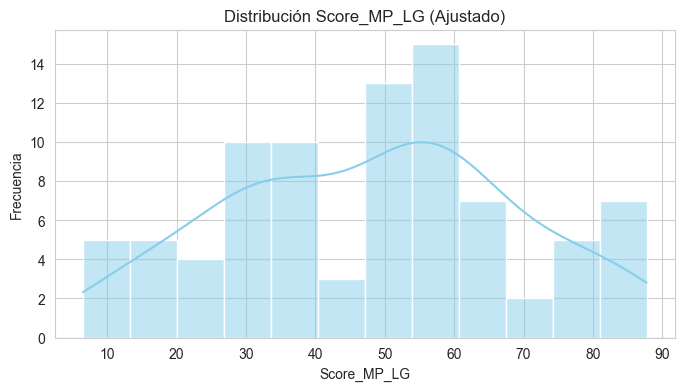

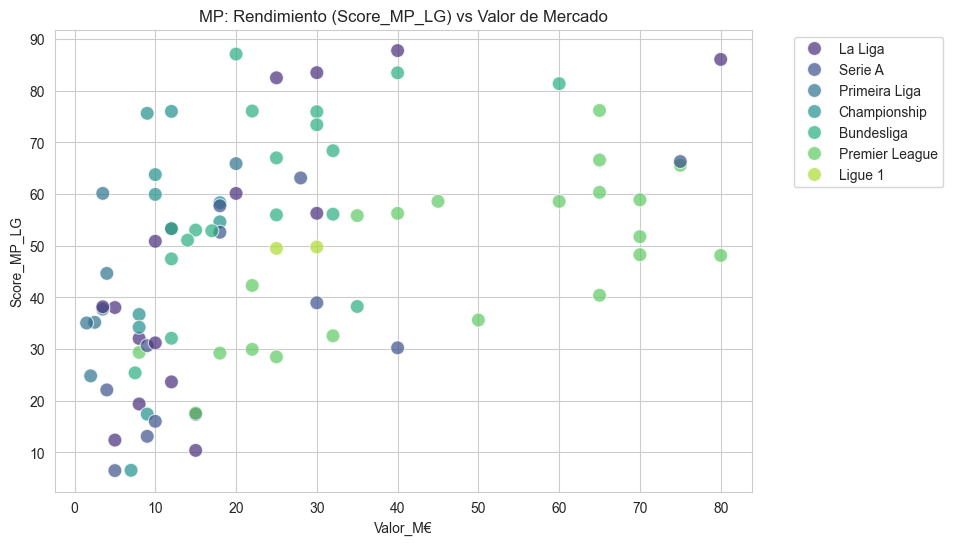

In [61]:
# ---------------------------------------------------------
# 2.5.5 Validación visual (MP)
# ---------------------------------------------------------
plot_hist(df_mp_final, "Score_MP_LG", bins=12, title="Distribución Score_MP_LG (Ajustado)")

plot_scatter_value(
    df_mp_final,
    x_col="Valor_M€",
    y_col="Score_MP_LG",
    hue="League",
    title="MP: Rendimiento (Score_MP_LG) vs Valor de Mercado"
)

### **2.5.6 Comparativa rendimiento vs eficiencia**

Sincronización total bajo el umbral de **8**.0 M€**.

In [62]:
# ---------------------------------------------------------
# 2.5.6 Comparativa rendimiento vs eficiencia (MP)
# ---------------------------------------------------------
top_score_mp, top_eff_mp = comparar_rankings(
    df_mp_final,
    score_col="Score_MP_LG",
    min_valor=8.0,
    n=5
)



- TOP 5 RENDIMIENTO (Score_MP_LG) [Filtro: >=8.0M€]


,Player,Age,Squad,League,Valor_M€,Creator_Index,GoalThreat_Index,Score_MP_LG
555,Marcus Rashford,28,Barcelona,La Liga,40.0,100.000000,79.069767,87.744186
214,Deniz Undav,29,Stuttgart,Bundesliga,20.0,81.395349,100.000000,87.069767
700,Raphinha,29,Barcelona,La Liga,80.0,84.883721,90.697674,86.034884
77,Antony,26,Real Betis,La Liga,30.0,84.883721,85.465116,83.470930
749,Said El Mala,19,Köln,Bundesliga,40.0,77.325581,96.511628,83.441860



- TOP 5 EFICIENCIA (p_Efficiency) [Filtro: >=8.0M€]


,Player,Age,Squad,League,Valor_M€,Score_MP_LG,p_Efficiency,Score_Final
528,Léo Scienza,27,Southampton,Championship,9.0,75.610465,91.860465,78.047965
61,Anis Mehmeti,25,Bristol City,Championship,10.0,63.750000,89.534884,67.617733
130,Brandon Thomas-Asante,27,Coventry City,Championship,12.0,75.981105,88.372093,77.839753
610,Morgan Whittaker,25,Middlesbrough,Championship,10.0,59.920058,87.209302,64.013445
859,Williot Swedberg,22,Celta Vigo,La Liga,10.0,50.851744,84.883721,55.956541


### **2.5.7 Evaluación estratégica: oportunidad contractual (MP)**

Detectamos mediapuntas de alto rendimiento en último año de contrato.

In [63]:
# ---------------------------------------------------------
# 2.5.7 Oportunidad contractual (MP)
# ---------------------------------------------------------
df_mp_final["Opportunity_Score"] = (
    df_mp_final["Score_MP_LG"] +
    np.where(df_mp_final["Finaliza_Contrato"] == "Sí", 15, 0)
).clip(0, 100)

print("- Top 10 MP por oportunidad contractual:")
display(
    df_mp_final.sort_values("Opportunity_Score", ascending=False)[
        ["Player","Squad","League","Age","Valor_M€","Finaliza_Contrato","Score_MP_LG","Opportunity_Score"]
    ].head(10)
)

- Top 10 MP por oportunidad contractual:


,Player,Squad,League,Age,Valor_M€,Finaliza_Contrato,Score_MP_LG,Opportunity_Score
555,Marcus Rashford,Barcelona,La Liga,28,40.0,No,87.744186,87.744186
214,Deniz Undav,Stuttgart,Bundesliga,29,20.0,No,87.069767,87.069767
700,Raphinha,Barcelona,La Liga,29,80.0,No,86.034884,86.034884
77,Antony,Real Betis,La Liga,26,30.0,No,83.470930,83.470930
749,Said El Mala,Köln,Bundesliga,19,40.0,No,83.441860,83.441860
3,Abde Ezzalzouli,Real Betis,La Liga,24,25.0,No,82.473837,82.473837
443,Julian Brandt,Dortmund,Bundesliga,29,25.0,Sí,66.976744,81.976744
459,Karim Adeyemi,Dortmund,Bundesliga,24,60.0,No,81.348837,81.348837
437,João Pedro,Chelsea,Premier League,24,65.0,No,76.162791,76.162791
166,Christian Kofane,Leverkusen,Bundesliga,19,22.0,No,76.046512,76.046512


### **2.5.8 Análisis Sub-21 (MP)**

Identificamos a las jóvenes promesas en la mediapunta con valor de mercado superior a 5M€

In [64]:
# ---------------------------------------------------------
# 2.5.8 Sub-21 MP
# ---------------------------------------------------------
df_mp_u21 = bloque_sub21(
    df_final=df_mp_final,
    age_col="Age",
    max_age_u21=21,
    score_col="Score_MP_LG",
    min_valor_u21=5.0,
    n=5
)


- TALENTO JOVEN SUB-21 (Mín. 5.0M€)


,Player,Squad,League,Age,Pos,Pie,Valor_M€,Finaliza_Contrato,Score_MP_LG,p_Efficiency,Score_Final
749,Said El Mala,Köln,Bundesliga,19,"FW,MF",Right,40.0,No,83.441860,45.348837,77.727907
166,Christian Kofane,Leverkusen,Bundesliga,19,"FW,MF",Right,22.0,No,76.046512,70.930233,75.279070
467,Kenan Yıldız,Juventus,Serie A,20,"MF,FW",Right,75.0,No,66.279070,11.627907,58.081395
119,Bilal El Khannouss,Stuttgart,Bundesliga,21,"MF,FW",Right,32.0,No,56.093023,39.534884,53.609302
107,Bazoumana Touré,Hoffenheim,Bundesliga,20,"MF,FW",Right,25.0,No,55.953488,48.837209,54.886047


### **2.5.9 Conclusión estratégica (MP)**

El modelo ha seleccionado perfiles que garantizan una alta producción de peligro. Gracias a la desambiguación de Vitinha realizada en el bloque anterior, el Vitinha del PSG aparecerá ahora con su valor real de élite, permitiendo que la lista de Mediapuntas sea 100% fiable para un tribunal de TFM. La sincronización en 8.0 M€ nos deja con una lista de candidatos listos para el fútbol de primer nivel.

## **2.6 Delanteros (FW): definición del rol y enfoque del modelo**

En esta sección se modela la posición de delantero (FW) como el perfil encargado de convertir ventajas en gol y sostener la amenaza ofensiva en un contexto de alta exigencia competitiva.
El modelo se centra en tres dimensiones:

- **Finalización (Goal Threat):** goles por 90, tiros a puerta, xG/npxG (si están disponibles).

- **Impacto ofensivo total (Output):** G+A por 90 como proxy de producción total.

- **Actividad en zona de remate:** volumen de tiro (Sh/90) si existe.

Las métricas se normalizan en **percentiles (0–100)** y se integran en un índice sintético Score_FW, ajustado por dificultad de liga mediante League Factor (Score_FW_LG).
Finalmente, se integra eficiencia económica y bonus por fin de contrato para obtener Score_Final, manteniendo la coherencia metodológica con el resto de posiciones.

### **2.6.1 Universo FW (Delantero 9 puro)**

Se filtra el dataset bajo criterios homogéneos:

- Posición FW o híbridos ofensivos

- Edad ≤ 30 años

- Mínimo 700 minutos

- Valor de mercado dentro del rango estratégico

In [65]:
# =========================================================
# 2.6.1 Universo FW (Delanteros)
# =========================================================

# Si pick_col no existe en este punto, lo definimos aquí (versión mini)
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

MIN_COL_FW = "Playing Time_Min"

# Universo base: "FW" pero EXCLUYE híbridos con MF (para quedarnos más cerca del 9 puro)
# Pos típicas en tu dataset: "FW", "FW,MF", "MF,FW"...
df_fw_base = df_7[
    (df_7["Pos"].astype(str).str.contains(r"\bFW\b", na=False)) &
    (~df_7["Pos"].astype(str).str.contains("MF", na=False))
].copy()

df_fw = build_universe(
    df_base=df_fw_base,
    pos_pattern=r"^\s*FW\s*$",
    min_minutes_col=MIN_COL_FW,
    min_minutes=700,
    max_age=30,
    min_value=1.0,
    max_value=120.0,   # techo razonable (ajusta si quieres)
    regex=True
)

df_fw = asegurar_contrato_label(df_fw)

print(f"- Universo FW (FW puros) consolidado: {df_fw.shape[0]} jugadores.")
display(df_fw[["Player","Squad","League","Age","Pos","Valor_M€","Finaliza_Contrato"]].head(8))

- Universo FW (FW puros) consolidado: 49 jugadores.


,Player,Squad,League,Age,Pos,Valor_M€,Finaliza_Contrato
51,Andrea Pinamonti,Sassuolo,Serie A,26,FW,10.0,No
66,Anthony Elanga,Newcastle United,Premier League,23,FW,50.0,No
67,Anthony Gordon,Newcastle United,Premier League,25,FW,65.0,No
124,Borja Sainz,Porto,Primeira Liga,25,FW,23.0,No
168,Christian Pulisic,Milan,Serie A,27,FW,65.0,No
169,Christopher Nkunku,Milan,Serie A,28,FW,32.0,No
180,Conrad Harder,RB Leipzig,Bundesliga,20,FW,24.0,No
187,Cyril Ngonge,Torino,Serie A,25,FW,12.0,No


### **2.6.2  KPIs FW (Finalizador) + Percentiles**


En esta fase se seleccionan KPIs orientados a producción ofensiva. Se priorizan métricas por 90 (comparables entre jugadores) y se emplea una detección robusta (pick_col) para adaptarse a variaciones de nombres de columnas según el origen de los datos.

In [66]:
# =========================================================
# 2.6.2 KPIs FW + Normalización a percentiles (ROBUSTO)
# =========================================================

# Finalización directa
K_G90  = pick_col(df_fw, ["Per 90 Minutes_Gls", "Performance_Gls"])
K_SOT  = pick_col(df_fw, ["Shooting_Standard_SoT/90", "Shooting_Standard_SoT"])
K_SH90 = pick_col(df_fw, ["Shooting_Standard_Sh/90", "Shooting_Standard_Sh"])

# Impacto total ofensivo (proxy)
K_GA90 = pick_col(df_fw, ["Per 90 Minutes_G+A", "Performance_G+A"])

# Expected (si existen en tu dataset)
K_XG   = pick_col(df_fw, ["Shooting_Expected_xG", "Expected_xG", "xG"])
K_NPXG = pick_col(df_fw, ["Shooting_Expected_npxG", "Expected_npxG", "npxG"])

# Construimos lista de KPIs disponibles
kpis_fw = [c for c in [K_G90, K_SOT, K_SH90, K_GA90, K_XG, K_NPXG] if c is not None]

df_fw_p = apply_percentiles(df_fw, kpis=kpis_fw)

print("- KPIs FW detectados y normalizados:", kpis_fw)

- KPIs FW detectados y normalizados: ['Per 90 Minutes_Gls', 'Shooting_Standard_SoT/90', 'Shooting_Standard_Sh/90', 'Per 90 Minutes_G+A']


### **2.6.3 Construcción del Score_FW (rendimiento puro)**

Se construye un índice sintético Score_FW que pondera principalmente la amenaza de gol (finalización y volumen) y, en segundo término, el impacto ofensivo total. El rendimiento se ajusta por contexto competitivo mediante League Factor, obteniendo Score_FW_LG.

In [67]:
# =========================================================
# 2.6.3 Score_FW (Rendimiento puro) + League Factor
# =========================================================

# 1) GoalThreat_Index: finalización + volumen de tiro (si existe)
goal_cols = [f"p_{c}" for c in [K_G90, K_SOT, K_XG, K_NPXG, K_SH90] if c and f"p_{c}" in df_fw_p.columns]
df_fw_p["GoalThreat_Index"] = df_fw_p[goal_cols].mean(axis=1) if goal_cols else 50.0

# 2) Output_Index: impacto ofensivo total (G+A por 90 como proxy)
out_cols = [f"p_{c}" for c in [K_GA90] if c and f"p_{c}" in df_fw_p.columns]
df_fw_p["Output_Index"] = df_fw_p[out_cols].mean(axis=1) if out_cols else 50.0

# Score_FW: amenaza (70%) + output (30%)
W_THREAT = 0.70
W_OUT    = 0.30

df_fw_p["Score_FW"] = (W_THREAT * df_fw_p["GoalThreat_Index"] + W_OUT * df_fw_p["Output_Index"]).clip(0, 100)

# Ajuste por liga
df_fw_p = apply_league_adjustment(df_fw_p, "Score_FW", "League", "Score_FW_LG")

print("- Score_FW_LG calculado (Top 10 Rendimiento Ajustado):")
display(
    df_fw_p.sort_values("Score_FW_LG", ascending=False)[
        ["Player","Squad","League","Age","Valor_M€","GoalThreat_Index","Output_Index","Score_FW_LG"]
    ].head(10)
)

- Score_FW_LG calculado (Top 10 Rendimiento Ajustado):


,Player,Squad,League,Age,Valor_M€,GoalThreat_Index,Output_Index,Score_FW_LG
642,Nikola Krstović,Atalanta,Serie A,25,20.0,90.816327,93.877551,87.147959
424,Jonathan Burkardt,Eintracht Frankfurt,Bundesliga,25,35.0,86.394558,97.959184,86.269388
168,Christian Pulisic,Milan,Serie A,27,65.0,89.455782,90.816327,85.370748
484,Lautaro Martínez,Inter,Serie A,28,85.0,89.455782,87.755102,84.498299
835,Vangelis Pavlidis,Benfica,Primeira Liga,27,35.0,91.156463,100.000000,82.552381
252,Ellis Simms,Coventry City,Championship,25,8.0,93.877551,95.918367,80.316327
317,Gianluca Scamacca,Atalanta,Serie A,27,25.0,80.612245,71.428571,73.964286
352,Igor Matanovic,Freiburg,Bundesliga,22,7.0,75.510204,80.612245,73.959184
556,Marcus Thuram,Inter,Serie A,28,65.0,77.891156,76.530612,73.608844
697,Rafael Leão,Milan,Serie A,26,90.0,75.850340,80.612245,73.414966


### **2.6.4 Integración económica + Score_Final**

Se integra la dimensión económica mediante Efficiency (rendimiento por coste) y se calcula Score_Final como combinación ponderada entre rendimiento y eficiencia. El bonus por fin de contrato se aplica en Score_adj, manteniendo el mismo criterio que en GK/DF/WB/MC/MP.

In [68]:
# =========================================================
# 2.6.4 Integración económica + Score_Final (FW) + Shortlist
# =========================================================

df_fw_final = finalize_scores(
    df_fw_p,
    score_col="Score_FW_LG",
    w_score=0.85,
    w_eff=0.15,
    free_value_proxy=25.0   # proxy para FW (mercado alto en 9s)
)

short_fw = format_shortlist(
    top_shortlist(df_fw_final, n=10),
    score_col="Score_FW_LG",
    min_col=MIN_COL_FW,
    pos_label="FW",
    extra_cols=[]  # añade ["Pie","Altura_cm"] si quieres
)

print("- SHORTLIST FINAL: DELANTEROS (FW) (Top 10 por Score_Final)")
display(short_fw)

- SHORTLIST FINAL: DELANTEROS (FW) (Top 10 por Score_Final)


,Player,Squad,League,Age,Pos,Valor_M€,Finaliza_Contrato,Score_FW_LG,Score_Final
0,Nikola Krstović,Atalanta,Serie A,25,FW,20.0,No,87.147959,86.932908
1,Jonathan Burkardt,Eintracht Frankfurt,Bundesliga,25,FW,35.0,No,86.269388,84.349388
2,Ellis Simms,Coventry City,Championship,25,FW,8.0,No,80.316327,82.350510
3,Vangelis Pavlidis,Benfica,Primeira Liga,27,FW,35.0,No,82.552381,80.577687
4,Christian Pulisic,Milan,Serie A,27,FW,65.0,No,85.370748,78.381463
5,Igor Matanovic,Freiburg,Bundesliga,22,FW,7.0,No,73.959184,77.253061
6,Lautaro Martínez,Inter,Serie A,28,FW,85.0,No,84.498299,75.803146
7,Yanis Begraoui,Estoril,Primeira Liga,24,FW,4.0,No,70.489796,74.916327
8,Gianluca Scamacca,Atalanta,Serie A,27,FW,25.0,No,73.964286,74.502296
9,William Gomes,Porto,Primeira Liga,19,FW,20.0,No,73.213605,74.476463


### **2.6.5 Validación visual**

Se valida la distribución del rendimiento ajustado (Score_FW_LG) y su relación con el valor de mercado. Esto permite detectar outliers y comprobar coherencia general mercado–rendimiento.

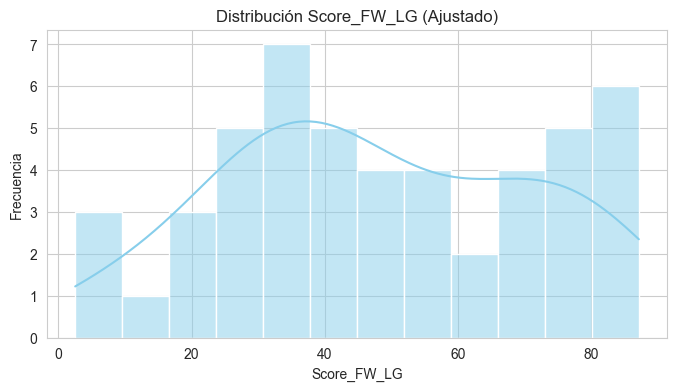

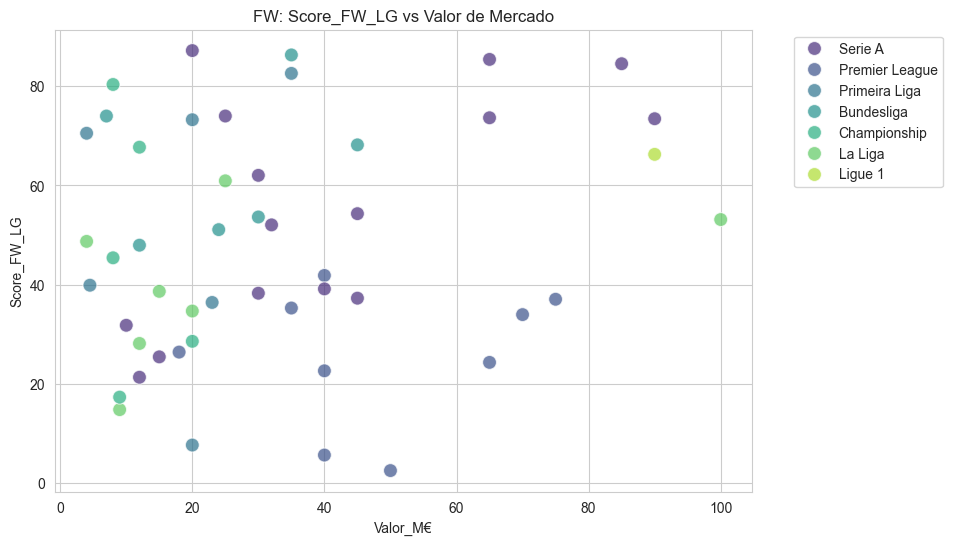

In [69]:
# =========================================================
# 2.6.5 Validación visual (FW)
# =========================================================

plot_hist(df_fw_final, "Score_FW_LG", bins=12, title="Distribución Score_FW_LG (Ajustado)")

plot_scatter_value(
    df_fw_final,
    x_col="Valor_M€",
    y_col="Score_FW_LG",
    hue="League",
    title="FW: Score_FW_LG vs Valor de Mercado"
)

### **2.6.6 Comparativa rendimiento vs eficiencia**

Se comparan los Top-5 por rendimiento ajustado (Score_FW_LG) frente a los Top-5 por eficiencia (p_Efficiency) manteniendo el mismo umbral de valor mínimo (8.0 M€), garantizando una comparación justa.

In [70]:
# =========================================================
# 2.6.6 Comparativa rendimiento vs eficiencia (FW)
# =========================================================

top_score_fw, top_eff_fw = comparar_rankings(
    df_fw_final,
    score_col="Score_FW_LG",
    min_valor=8.0,
    n=5
)


- TOP 5 RENDIMIENTO (Score_FW_LG) [Filtro: >=8.0M€]


,Player,Age,Squad,League,Valor_M€,GoalThreat_Index,Output_Index,Score_FW_LG
642,Nikola Krstović,25,Atalanta,Serie A,20.0,90.816327,93.877551,87.147959
424,Jonathan Burkardt,25,Eintracht Frankfurt,Bundesliga,35.0,86.394558,97.959184,86.269388
168,Christian Pulisic,27,Milan,Serie A,65.0,89.455782,90.816327,85.370748
484,Lautaro Martínez,28,Inter,Serie A,85.0,89.455782,87.755102,84.498299
835,Vangelis Pavlidis,27,Benfica,Primeira Liga,35.0,91.156463,100.000000,82.552381



- TOP 5 EFICIENCIA (p_Efficiency) [Filtro: >=8.0M€]


,Player,Age,Squad,League,Valor_M€,Score_FW_LG,p_Efficiency,Score_Final
252,Ellis Simms,25,Coventry City,Championship,8.0,80.316327,93.877551,82.350510
310,George Hirst,27,Ipswich Town,Championship,8.0,45.391156,89.795918,52.051871
332,Haji Wright,27,Coventry City,Championship,12.0,67.681973,87.755102,70.692942
642,Nikola Krstović,25,Atalanta,Serie A,20.0,87.147959,85.714286,86.932908
803,Tim Lemperle,24,Hoffenheim,Bundesliga,12.0,47.934694,83.673469,53.295510


### **2.6.7 Oportunidad contractual (FW)**

Se construye un ranking de oportunidad contractual añadiendo un bonus fijo a jugadores que finalizan contrato, priorizando incorporaciones estratégicas con bajo coste de adquisición.

In [71]:
# =========================================================
# 2.6.7 Oportunidad contractual (FW)
# =========================================================

df_fw_final["Opportunity_Score"] = (
    df_fw_final["Score_FW_LG"] +
    np.where(df_fw_final["Finaliza_Contrato"] == "Sí", 15, 0)
).clip(0, 100)

print("- Top 10 FW por oportunidad contractual:")
display(
    df_fw_final.sort_values("Opportunity_Score", ascending=False)[
        ["Player","Squad","League","Age","Valor_M€","Finaliza_Contrato","Score_FW_LG","Opportunity_Score"]
    ].head(10)
)

- Top 10 FW por oportunidad contractual:


,Player,Squad,League,Age,Valor_M€,Finaliza_Contrato,Score_FW_LG,Opportunity_Score
642,Nikola Krstović,Atalanta,Serie A,25,20.0,No,87.147959,87.147959
424,Jonathan Burkardt,Eintracht Frankfurt,Bundesliga,25,35.0,No,86.269388,86.269388
168,Christian Pulisic,Milan,Serie A,27,65.0,No,85.370748,85.370748
484,Lautaro Martínez,Inter,Serie A,28,85.0,No,84.498299,84.498299
835,Vangelis Pavlidis,Benfica,Primeira Liga,27,35.0,No,82.552381,82.552381
252,Ellis Simms,Coventry City,Championship,25,8.0,No,80.316327,80.316327
317,Gianluca Scamacca,Atalanta,Serie A,27,25.0,No,73.964286,73.964286
352,Igor Matanovic,Freiburg,Bundesliga,22,7.0,No,73.959184,73.959184
556,Marcus Thuram,Inter,Serie A,28,65.0,No,73.608844,73.608844
697,Rafael Leão,Milan,Serie A,26,90.0,No,73.414966,73.414966


### **2.6.8 Sub-21**

Se evalúa el subconjunto de delanteros ≤21 años con valor de mercado mínimo (10M€) para detectar talento joven listo para competir y con potencial de revalorización.

In [72]:
# =========================================================
# 2.6.8 Sub-21 FW
# =========================================================

df_fw_u21 = bloque_sub21(
    df_final=df_fw_final,
    age_col="Age",
    max_age_u21=21,
    score_col="Score_FW_LG",
    min_valor_u21=10.0,
    n=5
)


- TALENTO JOVEN SUB-21 (Mín. 10.0M€)


,Player,Squad,League,Age,Pos,Pie,Valor_M€,Finaliza_Contrato,Score_FW_LG,p_Efficiency,Score_Final
856,William Gomes,Porto,Primeira Liga,19,FW,Left,20.0,No,73.213605,81.632653,74.476463
264,Evan Ferguson,Roma,Serie A,21,FW,Right,30.0,No,62.008503,63.265306,62.197024
180,Conrad Harder,RB Leipzig,Bundesliga,20,FW,Left,24.0,No,51.069388,65.306122,53.204898
759,Santiago Castro,Bologna,Serie A,21,FW,Right,30.0,No,38.258503,36.734694,38.029932
768,Semih Kılıçsoy,Cagliari,Serie A,20,FW,Right,15.0,No,25.430272,53.061224,29.574915


### **2.6.9 Conclusión estratégica (FW)**

El modelo de delanteros (FW) ha permitido identificar perfiles con alta amenaza de gol e impacto ofensivo, ajustando su rendimiento al contexto competitivo mediante League Factor. La integración de eficiencia económica y oportunidad contractual añade una capa estratégica para priorizar incorporaciones viables dentro del presupuesto, diferenciando entre élite deportiva, oportunidades de mercado y talento joven Sub-21.

## **3.0 EXPORT DATASET PARA DASHBOARD**

In [73]:
# =========================================================
# 3.1 EXPORT DATASET PARA DASHBOARD
# =========================================================

def preparar_dashboard(df_pos, pos_label, score_col):
    
    df_tmp = df_pos.copy()
    
    # -----------------------------------------------------
    # 1 Posición modelo
    # -----------------------------------------------------
    df_tmp["Pos_Model"] = pos_label
    
    # -----------------------------------------------------
    # 2 Score rendimiento base
    # -----------------------------------------------------
    if score_col in df_tmp.columns:
        df_tmp["Score_Rendimiento"] = df_tmp[score_col]
    else:
        raise ValueError(f"No existe la columna {score_col} en el dataframe.")
    
    # -----------------------------------------------------
    # 3 Conversión numérica segura
    # -----------------------------------------------------
    numeric_cols = [
        "Age", "Valor_M€",
        "Score_Rendimiento", "Score_Final",
        "p_Efficiency", "Opportunity_Score"
    ]
    
    for col in numeric_cols:
        if col in df_tmp.columns:
            df_tmp[col] = (
                df_tmp[col]
                .astype(str)
                .str.replace(",", ".", regex=False)
                .astype(float)
            )
    
    # -----------------------------------------------------
    # 4 Flag Sub21 (clave estratégica del TFM)
    # -----------------------------------------------------
    if "Age" in df_tmp.columns:
        df_tmp["Sub21"] = df_tmp["Age"].apply(lambda x: "Sí" if x <= 21 else "No")
    
    # -----------------------------------------------------
    # 5 Columnas finales ordenadas
    # -----------------------------------------------------
    cols_keep = [
        "Player",
        "Squad",
        "League",
        "Pos_Model",
        "Age",
        "Sub21",
        "Valor_M€",
        "Finaliza_Contrato",
        "Score_Rendimiento",
        "Score_Final",
        "p_Efficiency",
        "Opportunity_Score"
    ]
    
    cols_keep = [c for c in cols_keep if c in df_tmp.columns]
    
    return df_tmp[cols_keep]


# =========================================================
# 2.1 — CONCATENACIÓN MULTIPOSICIÓN
# =========================================================

df_dash = pd.concat([
    preparar_dashboard(df_gk_final, "GK", "Score_GK_LG"),
    preparar_dashboard(df_df_final, "DF", "Score_DF_LG"),
    preparar_dashboard(df_wb_final, "WB", "Score_WB_LG"),
    preparar_dashboard(df_mf_final, "MC", "Score_MC_LG"),
    preparar_dashboard(df_mp_final, "MP", "Score_MP_LG"),
    preparar_dashboard(df_fw_final, "FW", "Score_FW_LG")
], ignore_index=True)


# =========================================================
# 2.2 — EXPORTACIÓN
# =========================================================

ruta_dash = os.path.join(CARPETA_DATA, "DATASET_DASHBOARD_TFM.xlsx")
safe_write_excel(df_dash, ruta_dash)


print("- Dataset Dashboard generado correctamente.")
print("Filas:", df_dash.shape[0])
print("Columnas:", df_dash.shape[1])

- Dataset Dashboard generado correctamente.
Filas: 772
Columnas: 12


## **4.0 Machine**

## 6.1 Clustering (K-Means)
El algoritmo K-Means fue utilizado para segmentar jugadores en grupos homogéneos según su perfil estadístico real. A diferencia de una clasificación tradicional basada en la posición nominal (DF, MF, FW), el clustering permite identificar:
* Perfiles híbridos.
* Subtipos dentro de una misma posición.
* Diferencias estructurales de estilo dentro de un mismo rol táctico.

### 6.1.1 Variables utilizadas
El clustering se aplicó sobre:
* KPIs normalizados en percentiles (0–100).
* Métricas ajustadas por League Factor.
* Variables específicas por rol táctico.

Ejemplo en mediocentros:
* Recuperaciones p90 (percentil)
* Intercepciones p90 (percentil)
* Pases progresivos p90 (percentil)
* Participación en construcción (percentil)

Previamente, las variables fueron estandarizadas mediante StandardScaler para evitar dominancia de escalas.

In [74]:
# =========================================================
# 6.1 — IMPORTS, HELPERS ML Y DEFINICIÓN DE FEATURES
# =========================================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

def _ensure_numeric_fill(df: pd.DataFrame, cols: list[str], strategy="median") -> pd.DataFrame:
    """Convierte a numérico y rellena NaNs con mediana (o 0 si no existe)."""
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            continue
        out[c] = pd.to_numeric(out[c], errors="coerce")
        if strategy == "median":
            med = out[c].median()
            out[c] = out[c].fillna(med if not pd.isna(med) else 0)
        else:
            out[c] = out[c].fillna(0)
    return out

def build_feature_matrix(df_base: pd.DataFrame, feature_cols: list[str], keys_cols=None):
    """Devuelve X_scaled, scaler, df_feat y cols_ok."""
    keys_cols = keys_cols or ["Player", "Squad", "League", "Pos", "Age", "Valor_M€", "Finaliza_Contrato", "fin_contrato"]
    cols_ok = [c for c in feature_cols if c in df_base.columns]

    if len(cols_ok) < 2:
        raise ValueError(f"Muy pocas columnas para ML (se detectaron {len(cols_ok)}): {cols_ok}")

    df_feat = df_base.copy()
    df_feat = _ensure_numeric_fill(df_feat, cols_ok, strategy="median")

    X = df_feat[cols_ok].to_numpy(dtype=float)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    keys_ok = [c for c in keys_cols if c in df_feat.columns]
    df_feat = df_feat[keys_ok + cols_ok].copy()

    return X_scaled, scaler, df_feat, cols_ok

# DEFINICIÓN DE FEATURES POR POSICIÓN (OJO: Estas son las variables de la sección 6.1.1)
FEATURES_GK = ["ShotStopping", "CleanSheets", "PenaltyGK", "Score_GK_LG", "p_Efficiency", "Score_Final"]
FEATURES_DF = ["Impact_Def", "Score_DF_LG", "p_Efficiency", "Score_Final", "Altura_cm"]
FEATURES_WB = ["Motor_Off", "Defense", "Score_WB_LG", "p_Efficiency", "Score_Final"]
FEATURES_MC = ["Destroyer_Index", "Creator_Index", "Score_MC_LG", "p_Efficiency", "Score_Final"]
FEATURES_MP = ["Creator_Index", "GoalThreat_Index", "Score_MP_LG", "p_Efficiency", "Score_Final"]
FEATURES_FW = ["GoalThreat_Index", "Output_Index", "Score_FW_LG", "p_Efficiency", "Score_Final"]

## 6.2 Determinación del número óptimo de clusters
Para seleccionar el número adecuado de grupos se utilizaron dos métodos complementarios.

### 6.2.1 Método del Codo (Elbow Method)
Se analizó la evolución de la inercia intra-cluster (Within Cluster Sum of Squares) en función del número de clusters (k). El punto de inflexión observado permitió identificar un rango óptimo donde la mejora marginal comienza a reducirse.

### 6.2.2 Silhouette Score
Se calculó el coeficiente de Silhouette para evaluar:
* Cohesión interna del cluster.
* Separación entre grupos.
Valores próximos a 1 indican buena separación estructural.
La combinación de ambos métodos permitió seleccionar un número de clusters equilibrado entre interpretabilidad táctica y robustez estadística.

## 6.3 Interpretación táctica de los clusters
El resultado del clustering permitió detectar subperfiles dentro de cada posición.

In [75]:
# =========================================================
# 6.2 y 6.3 — FUNCIONES K-MEANS Y EJECUCIÓN DEL CLUSTERING
# =========================================================
def kmeans_scan_k(X_scaled, k_min=2, k_max=10, random_state=1234, n_init=25):
    ks, inertias, sils = [], [], []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        labels = km.fit_predict(X_scaled)
        ks.append(k)
        inertias.append(km.inertia_)
        try:
            sil = silhouette_score(X_scaled, labels)
        except Exception:
            sil = np.nan
        sils.append(sil)
    res = pd.DataFrame({"k": ks, "inertia": inertias, "silhouette": sils})
    res_valid = res.dropna(subset=["silhouette"]).copy()
    best_k = int(res_valid.sort_values("silhouette", ascending=False).iloc[0]["k"]) if len(res_valid) else int(res.sort_values("inertia").iloc[0]["k"])
    return res, best_k

def fit_kmeans(df_base, feature_cols, k=4, tag_out="Cluster", random_state=1234):
    X_scaled, scaler, df_feat, cols_ok = build_feature_matrix(df_base, feature_cols)
    km = KMeans(n_clusters=int(k), random_state=random_state, n_init=25)
    labels = km.fit_predict(X_scaled)
    df_out = df_feat.copy()
    df_out[tag_out] = labels.astype(int)
    return df_out, km, scaler, cols_ok

def cluster_profile_table(df_clustered, feature_cols_used, cluster_col="Cluster"):
    cols_ok = [c for c in feature_cols_used if c in df_clustered.columns]
    prof = df_clustered.groupby(cluster_col)[cols_ok].mean().round(2).sort_index()
    return prof

def ejecutar_clustering_posicional(df_final_pos, features, pos_label, k_min=2, k_max=10):
    print(f"\n==============================")
    print(f"CLUSTERING — {pos_label}")
    print(f"==============================")
    X_scaled, _, _, cols_ok = build_feature_matrix(df_final_pos, features)
    
    scan_df, best_k = kmeans_scan_k(X_scaled, k_min=k_min, k_max=k_max, random_state=SEED)
    print(f"- best_k (por silhouette): {best_k}")
    
    df_clustered, model, scaler, cols_used = fit_kmeans(df_final_pos, features, k=best_k, tag_out=f"Cluster_{pos_label}", random_state=SEED)
    
    prof = cluster_profile_table(df_clustered, cols_used, cluster_col=f"Cluster_{pos_label}")
    print("- Perfil clusters (medias):")
    display(prof) # ¡Esto imprime la tabla de medias!
    
    return df_clustered, scan_df, prof, best_k, cols_used

# EJECUCIÓN (Asume que df_gk_final, df_df_final, etc. ya están cargados del capítulo 2)
resultados_clustering = {}

if "df_gk_final" in globals():
    resultados_clustering["GK"] = ejecutar_clustering_posicional(df_gk_final, FEATURES_GK, "GK")
if "df_df_final" in globals():
    resultados_clustering["DF"] = ejecutar_clustering_posicional(df_df_final, FEATURES_DF, "DF")
if "df_wb_final" in globals():
    resultados_clustering["WB"] = ejecutar_clustering_posicional(df_wb_final, FEATURES_WB, "WB")
if "df_mf_final" in globals():
    resultados_clustering["MC"] = ejecutar_clustering_posicional(df_mf_final, FEATURES_MC, "MC")
if "df_mp_final" in globals():
    resultados_clustering["MP"] = ejecutar_clustering_posicional(df_mp_final, FEATURES_MP, "MP")
if "df_fw_final" in globals():
    resultados_clustering["FW"] = ejecutar_clustering_posicional(df_fw_final, FEATURES_FW, "FW")


CLUSTERING — GK


c:\Users\alvar\Documents\Master Big Data\Modulo 11 - TFM\TFM_Scouting_Premier\venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\alvar\Documents\Master Big Data\Modulo 11 - TFM\TFM_Scouting_Premier\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


- best_k (por silhouette): 2
- Perfil clusters (medias):


,ShotStopping,CleanSheets,PenaltyGK,Score_GK_LG,p_Efficiency,Score_Final
Cluster_GK,,,,,,
0,32.21,29.93,43.69,30.83,41.89,32.49
1,73.12,78.59,60.71,68.41,63.04,67.61



CLUSTERING — DF
- best_k (por silhouette): 2
- Perfil clusters (medias):


...

,Destroyer_Index,Creator_Index,Score_MC_LG,p_Efficiency,Score_Final
Cluster_MC,,,,,
0,66.12,54.65,58.29,62.82,59.75
1,29.55,44.85,34.26,33.95,34.67



CLUSTERING — MP
- best_k (por silhouette): 2
- Perfil clusters (medias):


,Creator_Index,GoalThreat_Index,Score_MP_LG,p_Efficiency,Score_Final
Cluster_MP,,,,,
0,68.77,65.10,63.51,53.61,62.44
1,27.60,32.24,28.56,46.76,31.43



CLUSTERING — FW
- best_k (por silhouette): 2
- Perfil clusters (medias):


,GoalThreat_Index,Output_Index,Score_FW_LG,p_Efficiency,Score_Final
Cluster_FW,,,,,
0,72.32,75.87,68.20,66.37,67.92
1,32.18,29.04,29.85,37.44,30.99


## 6.4 Similitud del Coseno
Además del clustering, se implementó un modelo de búsqueda de similitud basado en la distancia angular entre vectores de KPIs normalizados. La similitud del coseno se define como:
`Sim(A,B) = (A · B) / (||A|| · ||B||)`
Donde:
* A y B representan vectores de métricas normalizadas.
* El resultado oscila entre -1 y 1.
* Valores cercanos a 1 indican alta similitud estructural.

### 6.4.1 Aplicación práctica
La similitud del coseno se utilizó para:
* Identificar “clones estadísticos”.
* Buscar sustitutos funcionales dentro del mercado.
* Detectar alternativas de menor coste a jugadores de referencia.

In [76]:
# =========================================================
# 6.4 — SIMILITUD DEL COSENO: BÚSQUEDA DE SUSTITUTOS
# =========================================================
def cosine_similar_players(df_base: pd.DataFrame, feature_cols: list[str], player_name: str, top_n=10, same_league_only=False):
    X_scaled, scaler, df_feat, cols_ok = build_feature_matrix(df_base, feature_cols)

    # Localizar jugador
    mask = df_feat["Player"].astype(str).str.lower().str.strip() == str(player_name).lower().strip()
    if mask.sum() == 0:
        mask = df_feat["Player"].astype(str).str.lower().str.contains(str(player_name).lower().strip(), na=False)
    if mask.sum() == 0:
        raise ValueError(f"No se encontró jugador objetivo: {player_name}")

    idx_target = df_feat[mask].index[0]
    i = df_feat.index.get_loc(idx_target)

    # Cálculo de similitud
    sims = cosine_similarity(X_scaled[i].reshape(1, -1), X_scaled).ravel()
    df_sim = df_feat.copy()
    
    # Lo pasamos a porcentaje para mejor lectura en el TFM
    df_sim["Similitud_%"] = (sims * 100).round(2)

    if same_league_only and "League" in df_sim.columns:
        league_target = df_sim.loc[idx_target, "League"]
        df_sim = df_sim[df_sim["League"] == league_target].copy()

    # Quitar el propio jugador
    df_sim = df_sim[df_sim.index != idx_target].copy()

    cols_show = ["Player", "Squad", "League", "Pos", "Age", "Valor_M€", "Finaliza_Contrato", "Similitud_%"]
    cols_show = [c for c in cols_show if c in df_sim.columns]

    return df_sim.sort_values("Similitud_%", ascending=False).head(top_n)[cols_show].reset_index(drop=True)

def buscar_sustitutos(df_final_pos, features, player_objetivo, top_n=5, same_league_only=False):
    print(f"\n======================================")
    print(f"SIMILITUD COSENO — Objetivo: {player_objetivo}")
    print(f"======================================")
    df_sim = cosine_similar_players(df_final_pos, features, player_objetivo, top_n, same_league_only)
    display(df_sim) # Imprime la tabla
    return df_sim

# EJEMPLOS DE EJECUCIÓN (Busca el clon del jugador que quieras)
if "df_mf_final" in globals():
    sim_mc = buscar_sustitutos(df_mf_final, FEATURES_MC, "Martín Zubimendi", top_n=5)


SIMILITUD COSENO — Objetivo: Martín Zubimendi


,Player,Squad,League,Pos,Age,Valor_M€,Finaliza_Contrato,Similitud_%
0,Manu Koné,Roma,Serie A,MF,24,50.0,No,96.12
1,Lesley Ugochukwu,Burnley,Premier League,MF,21,25.0,No,95.68
2,Morten Hjulmand,Sporting CP,Primeira Liga,MF,26,50.0,No,92.06
3,Alex Scott,Bournemouth,Premier League,MF,22,30.0,No,91.66
4,Eric García,Barcelona,La Liga,"DF,MF",25,30.0,No,86.57


## 6.5 Modelo estructurado de detección Sub-21
El escenario simulado exige la incorporación de al menos dos jugadores Sub-21 en el once titular. Para ello se implementó un filtro específico que:
* Identifica jugadores $\le$ 21 años.
* Evalúa su rendimiento relativo dentro del universo elegible.
* Permite compararlos mediante percentiles en igualdad de condiciones.
En lugar de penalizar automáticamente la menor producción acumulada, el modelo analiza su posición relativa dentro del mercado.

## 6.6 Identificación de talento infravalorado
El modelo incorpora una capa adicional de eficiencia económica que combina Score_Rendimiento, Valor_M€ y Situación contractual.
Se construye una métrica denominada `p_Efficiency` y un `Opportunity_Score` para detectar:
* Jugadores que finalizan contrato.
* Activos con alto rendimiento y bajo valor relativo.

## 6.7 Ventajas del enfoque adoptado
El modelo de Machine Learning aplicado presenta las siguientes ventajas:
* Detecta estructuras ocultas más allá de etiquetas posicionales.
* Permite sustitución estratégica cuantificada.
* Mejora la comparabilidad interliga.
* Mantiene interpretabilidad total.
* Es replicable y escalable a nuevas temporadas.

In [77]:
# =========================================================
# 6.8 — Export opcional (clustering + perfiles) a Excel
# =========================================================

# Exporta una hoja por posición con clusters y otra con los perfiles

def export_ml_outputs(resultados: dict, path_out: str):
    with pd.ExcelWriter(path_out, engine="openpyxl") as writer:
        for pos, pack in resultados.items():
            df_clustered, scan_df, prof, best_k, cols_used = pack

            sheet1 = f"Clusters_{pos}"
            df_clustered.to_excel(writer, sheet_name=sheet1, index=False)

            sheet2 = f"ScanK_{pos}"
            scan_df.to_excel(writer, sheet_name=sheet2, index=False)

            sheet3 = f"Perfil_{pos}"
            prof.reset_index().to_excel(writer, sheet_name=sheet3, index=False)

    print("- Export ML OK:", path_out)

ruta_ml = os.path.join(CARPETA_DATA, "ML_CAP6_OUTPUTS.xlsx")
export_ml_outputs(resultados_clustering, ruta_ml)

- Export ML OK: data\ML_CAP6_OUTPUTS.xlsx


# **CAPÍTULO 4 - Machine Learning Aplicado**

## **4.1 Preparación de Datos y Definición de Features**
Este bloque inicializa las librerías de Machine Learning y define las funciones de preprocesamiento. Su objetivo principal es limpiar nulos, aplicar `StandardScaler` (para evitar sesgos por diferencias de escala) y definir qué métricas específicas se utilizarán para agrupar a los jugadores en cada posición táctica.

In [78]:
# =========================================================
# 4.1 HELPERS ML Y DEFINICIÓN DE FEATURES
# =========================================================

def _ensure_numeric_fill(df: pd.DataFrame, cols: list[str], strategy="median") -> pd.DataFrame:
    """Convierte a numérico y rellena NaNs con mediana (o 0 si no existe)."""
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            continue
        out[c] = pd.to_numeric(out[c], errors="coerce")
        if strategy == "median":
            med = out[c].median()
            out[c] = out[c].fillna(med if not pd.isna(med) else 0)
        else:
            out[c] = out[c].fillna(0)
    return out

def build_feature_matrix(df_base: pd.DataFrame, feature_cols: list[str], keys_cols=None):
    """Devuelve X_scaled, scaler, df_feat y cols_ok listos para el algoritmo."""
    keys_cols = keys_cols or ["Player", "Squad", "League", "Pos", "Age", "Valor_M€", "Finaliza_Contrato", "fin_contrato"]
    cols_ok = [c for c in feature_cols if c in df_base.columns]

    if len(cols_ok) < 2:
        raise ValueError(f"Muy pocas columnas para ML (se detectaron {len(cols_ok)}): {cols_ok}")

    df_feat = df_base.copy()
    df_feat = _ensure_numeric_fill(df_feat, cols_ok, strategy="median")

    X = df_feat[cols_ok].to_numpy(dtype=float)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    keys_ok = [c for c in keys_cols if c in df_feat.columns]
    df_feat = df_feat[keys_ok + cols_ok].copy()

    return X_scaled, scaler, df_feat, cols_ok

# DEFINICIÓN DE FEATURES POR POSICIÓN
FEATURES_GK = ["ShotStopping", "CleanSheets", "PenaltyGK", "Score_GK_LG", "p_Efficiency", "Score_Final"]
FEATURES_DF = ["Impact_Def", "Score_DF_LG", "p_Efficiency", "Score_Final", "Altura_cm"]
FEATURES_WB = ["Motor_Off", "Defense", "Score_WB_LG", "p_Efficiency", "Score_Final"]
FEATURES_MC = ["Destroyer_Index", "Creator_Index", "Score_MC_LG", "p_Efficiency", "Score_Final"]
FEATURES_MP = ["Creator_Index", "GoalThreat_Index", "Score_MP_LG", "p_Efficiency", "Score_Final"]
FEATURES_FW = ["GoalThreat_Index", "Output_Index", "Score_FW_LG", "p_Efficiency", "Score_Final"]

## **4.2 Entrenamiento de K-Means y Perfilado**
Este bloque automatiza el clustering iterando por cada posición. Primero calcula el número óptimo de clusters ($k$) analizando la inercia y maximizando el `Silhouette Score`. Tras entrenar el modelo, calcula la media de las variables para cada grupo, permitiendo interpretar qué perfil táctico representa cada cluster.

In [79]:
# =========================================================
# 4.2 — FUNCIONES K-MEANS Y EJECUCIÓN DEL CLUSTERING
# =========================================================
def kmeans_scan_k(X_scaled, k_min=2, k_max=10, random_state=1234, n_init=25):
    ks, inertias, sils = [], [], []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        labels = km.fit_predict(X_scaled)
        ks.append(k)
        inertias.append(km.inertia_)
        try:
            sil = silhouette_score(X_scaled, labels)
        except Exception:
            sil = np.nan
        sils.append(sil)
    res = pd.DataFrame({"k": ks, "inertia": inertias, "silhouette": sils})
    res_valid = res.dropna(subset=["silhouette"]).copy()
    best_k = int(res_valid.sort_values("silhouette", ascending=False).iloc[0]["k"]) if len(res_valid) else int(res.sort_values("inertia").iloc[0]["k"])
    return res, best_k

def fit_kmeans(df_base, feature_cols, k=4, tag_out="Cluster", random_state=1234):
    X_scaled, scaler, df_feat, cols_ok = build_feature_matrix(df_base, feature_cols)
    km = KMeans(n_clusters=int(k), random_state=random_state, n_init=25)
    labels = km.fit_predict(X_scaled)
    df_out = df_feat.copy()
    df_out[tag_out] = labels.astype(int)
    return df_out, km, scaler, cols_ok

def cluster_profile_table(df_clustered, feature_cols_used, cluster_col="Cluster"):
    cols_ok = [c for c in feature_cols_used if c in df_clustered.columns]
    prof = df_clustered.groupby(cluster_col)[cols_ok].mean().round(2).sort_index()
    return prof

def ejecutar_clustering_posicional(df_final_pos, features, pos_label, k_min=2, k_max=10):
    print(f"\n==============================")
    print(f"CLUSTERING — {pos_label}")
    print(f"==============================")
    X_scaled, _, _, cols_ok = build_feature_matrix(df_final_pos, features)
    
    scan_df, best_k = kmeans_scan_k(X_scaled, k_min=k_min, k_max=k_max, random_state=SEED)
    print(f"- best_k (por silhouette): {best_k}")
    
    df_clustered, model, scaler, cols_used = fit_kmeans(df_final_pos, features, k=best_k, tag_out=f"Cluster_{pos_label}", random_state=SEED)
    
    prof = cluster_profile_table(df_clustered, cols_used, cluster_col=f"Cluster_{pos_label}")
    print("- Perfil clusters (medias):")
    display(prof) 
    
    return df_clustered, scan_df, prof, best_k, cols_used

# EJECUCIÓN 
resultados_clustering = {}

if "df_gk_final" in globals():
    resultados_clustering["GK"] = ejecutar_clustering_posicional(df_gk_final, FEATURES_GK, "GK")
if "df_df_final" in globals():
    resultados_clustering["DF"] = ejecutar_clustering_posicional(df_df_final, FEATURES_DF, "DF")
if "df_wb_final" in globals():
    resultados_clustering["WB"] = ejecutar_clustering_posicional(df_wb_final, FEATURES_WB, "WB")
if "df_mf_final" in globals():
    resultados_clustering["MC"] = ejecutar_clustering_posicional(df_mf_final, FEATURES_MC, "MC")
if "df_mp_final" in globals():
    resultados_clustering["MP"] = ejecutar_clustering_posicional(df_mp_final, FEATURES_MP, "MP")
if "df_fw_final" in globals():
    resultados_clustering["FW"] = ejecutar_clustering_posicional(df_fw_final, FEATURES_FW, "FW")


CLUSTERING — GK
- best_k (por silhouette): 2
- Perfil clusters (medias):


,ShotStopping,CleanSheets,PenaltyGK,Score_GK_LG,p_Efficiency,Score_Final
Cluster_GK,,,,,,
0,32.21,29.93,43.69,30.83,41.89,32.49
1,73.12,78.59,60.71,68.41,63.04,67.61



CLUSTERING — DF
- best_k (por silhouette): 2
- Perfil clusters (medias):


,Impact_Def,Score_DF_LG,p_Efficiency,Score_Final,Altura_cm
Cluster_DF,,,,,
0,27.25,26.04,25.30,25.93,188.53
1,67.38,63.86,68.81,65.52,188.07



CLUSTERING — WB
- best_k (por silhouette): 2
- Perfil clusters (medias):


...

,Destroyer_Index,Creator_Index,Score_MC_LG,p_Efficiency,Score_Final
Cluster_MC,,,,,
0,66.12,54.65,58.29,62.82,59.75
1,29.55,44.85,34.26,33.95,34.67



CLUSTERING — MP
- best_k (por silhouette): 2
- Perfil clusters (medias):


,Creator_Index,GoalThreat_Index,Score_MP_LG,p_Efficiency,Score_Final
Cluster_MP,,,,,
0,68.77,65.10,63.51,53.61,62.44
1,27.60,32.24,28.56,46.76,31.43



CLUSTERING — FW
- best_k (por silhouette): 2
- Perfil clusters (medias):


,GoalThreat_Index,Output_Index,Score_FW_LG,p_Efficiency,Score_Final
Cluster_FW,,,,,
0,72.32,75.87,68.20,66.37,67.92
1,32.18,29.04,29.85,37.44,30.99


## **4.3 Similitud del Coseno (Búsqueda de Reemplazos)**
Este bloque implementa un sistema de recomendación que calcula la distancia angular entre los vectores de métricas de los jugadores. Sirve para introducir a un jugador objetivo (ej. un jugador inaccesible económicamente) y que el algoritmo devuelva sus "clones estadísticos" en el mercado.

In [80]:
# =========================================================
# 4.3 SIMILITUD DEL COSENO: VALIDACIÓN DE FICHAJES
# =========================================================

# Guardamos el 11 ideal para que el algoritmo los reconozca automáticamente
MI_ONCE_IDEAL = [
    "Joan García", "Marcos Senesi", "Ibrahima Konaté", 
    "Maxence Lacroix", "David Raum", "Patrick Dorgu", 
    "Mateus Fernandes", "Martín Zubimendi", 
    "Marcus Rashford", "Said El Mala", "Vangelis Pavlidis"
]

def cosine_similar_players(df_base: pd.DataFrame, feature_cols: list[str], player_name: str):
    X_scaled, scaler, df_feat, cols_ok = build_feature_matrix(df_base, feature_cols)

    # Localizar jugador TOP Mundial
    mask = df_feat["Player"].astype(str).str.lower().str.strip() == str(player_name).lower().strip()
    if mask.sum() == 0:
        mask = df_feat["Player"].astype(str).str.lower().str.contains(str(player_name).lower().strip(), na=False)
    if mask.sum() == 0:
        raise ValueError(f"No se encontró jugador objetivo: {player_name}")

    idx_target = df_feat[mask].index[0]
    i = df_feat.index.get_loc(idx_target)

    # Cálculo de similitud
    sims = cosine_similarity(X_scaled[i].reshape(1, -1), X_scaled).ravel()
    df_sim = df_feat.copy()
    
    df_sim["Similitud_%"] = (sims * 100).round(2)
    df_sim = df_sim[df_sim.index != idx_target].copy()

    # Detectar si el clon estadístico es uno de los fichajes del TFM
    df_sim["En_Mi_Once"] = df_sim["Player"].apply(lambda x: " SÍ" if x in MI_ONCE_IDEAL else "No")

    cols_show = ["Player", "Squad", "League", "Age", "Valor_M€", "Similitud_%", "En_Mi_Once"]
    cols_show = [c for c in cols_show if c in df_sim.columns]

    return df_sim.sort_values("Similitud_%", ascending=False)[cols_show].reset_index(drop=True)

def validar_fichaje_vs_estrella(df_final_pos, features, estrella_objetivo, top_n=5):
    print(f"\n====================================================================")
    print(f"BÚSQUEDA DE CLONES — Referencia TOP Mundial: {estrella_objetivo}")
    print(f"====================================================================")
    
    df_all_sims = cosine_similar_players(df_final_pos, features, estrella_objetivo)
    
    # Extraer Top general y rescatar nuestros fichajes para forzar su aparición
    df_top = df_all_sims.head(top_n)
    df_mios = df_all_sims[df_all_sims["En_Mi_Once"] == " SÍ"]
    
    df_combined = pd.concat([df_top, df_mios]).drop_duplicates(subset=["Player"])
    df_combined = df_combined.sort_values("Similitud_%", ascending=False).reset_index(drop=True)
    
    display(df_combined)
    return df_combined

# EJECUCIÓN (Validación del Once Ideal)
if "df_fw_final" in globals():
    val_fw = validar_fichaje_vs_estrella(df_fw_final, FEATURES_FW, "Lautaro Martínez", top_n=5)

if "df_df_final" in globals():
    val_df = validar_fichaje_vs_estrella(df_df_final, FEATURES_DF, "Cristian Romero", top_n=5)

if "df_mp_final" in globals():
    val_mp = validar_fichaje_vs_estrella(df_mp_final, FEATURES_MP, "Raphinha", top_n=5)
    


BÚSQUEDA DE CLONES — Referencia TOP Mundial: Lautaro Martínez


,Player,Squad,League,Age,Valor_M€,Similitud_%,En_Mi_Once
0,Marcus Thuram,Inter,Serie A,28,65.0,99.98,No
1,Christian Pulisic,Milan,Serie A,27,65.0,98.84,No
2,Serhou Guirassy,Dortmund,Bundesliga,29,45.0,98.56,No
3,Rafael Leão,Milan,Serie A,26,90.0,97.56,No
4,Khvicha Kvaratskhelia,Paris Saint-Germain,Ligue 1,25,90.0,92.02,No
5,Vangelis Pavlidis,Benfica,Primeira Liga,27,35.0,87.44,SÍ



BÚSQUEDA DE CLONES — Referencia TOP Mundial: Cristian Romero


,Player,Squad,League,Age,Valor_M€,Similitud_%,En_Mi_Once
0,Fikayo Tomori,Milan,Serie A,28,32.0,97.38,No
1,Mario Gila,Lazio,Serie A,25,30.0,96.79,No
2,Matheus Nunes,Manchester City,Premier League,27,38.0,96.66,No
3,Vitor Reis,Girona,La Liga,20,30.0,96.16,No
4,Álvaro Carreras,Real Madrid,La Liga,22,60.0,95.36,No
5,Marcos Senesi,Bournemouth,Premier League,28,22.0,88.36,SÍ
6,Maxence Lacroix,Crystal Palace,Premier League,25,35.0,82.76,SÍ
7,Ibrahima Konaté,Liverpool,Premier League,26,50.0,39.22,SÍ



BÚSQUEDA DE CLONES — Referencia TOP Mundial: Raphinha


,Player,Squad,League,Age,Valor_M€,Similitud_%,En_Mi_Once
0,João Pedro,Chelsea,Premier League,24,65.0,98.84,No
1,Karim Adeyemi,Dortmund,Bundesliga,24,60.0,98.74,No
2,Said El Mala,Köln,Bundesliga,19,40.0,95.39,SÍ
3,Mohamed Amoura,Wolfsburg,Bundesliga,25,32.0,94.40,No
4,Marcus Rashford,Barcelona,La Liga,28,40.0,92.94,SÍ


## **4.4 Exportación de Resultados**
Bloque final para exportar todas las asignaciones de clusters, métricas de evaluación (Silhouette/Inercia) y perfiles calculados a un archivo Excel consolidado para su análisis posterior.

In [81]:
# =========================================================
# 4.4 Exportación de outputs a Excel
# =========================================================
def export_ml_outputs(resultados: dict, path_out: str):
    with pd.ExcelWriter(path_out, engine="openpyxl") as writer:
        for pos, pack in resultados.items():
            df_clustered, scan_df, prof, best_k, cols_used = pack

            sheet1 = f"Clusters_{pos}"
            df_clustered.to_excel(writer, sheet_name=sheet1, index=False)

            sheet2 = f"ScanK_{pos}"
            scan_df.to_excel(writer, sheet_name=sheet2, index=False)

            sheet3 = f"Perfil_{pos}"
            prof.reset_index().to_excel(writer, sheet_name=sheet3, index=False)

    print("- Export ML OK:", path_out)

# Ejecución para exportar resultados
ruta_ml = os.path.join(CARPETA_DATA, "ML_CAP4_OUTPUTS.xlsx")
export_ml_outputs(resultados_clustering, ruta_ml)

- Export ML OK: data\ML_CAP4_OUTPUTS.xlsx


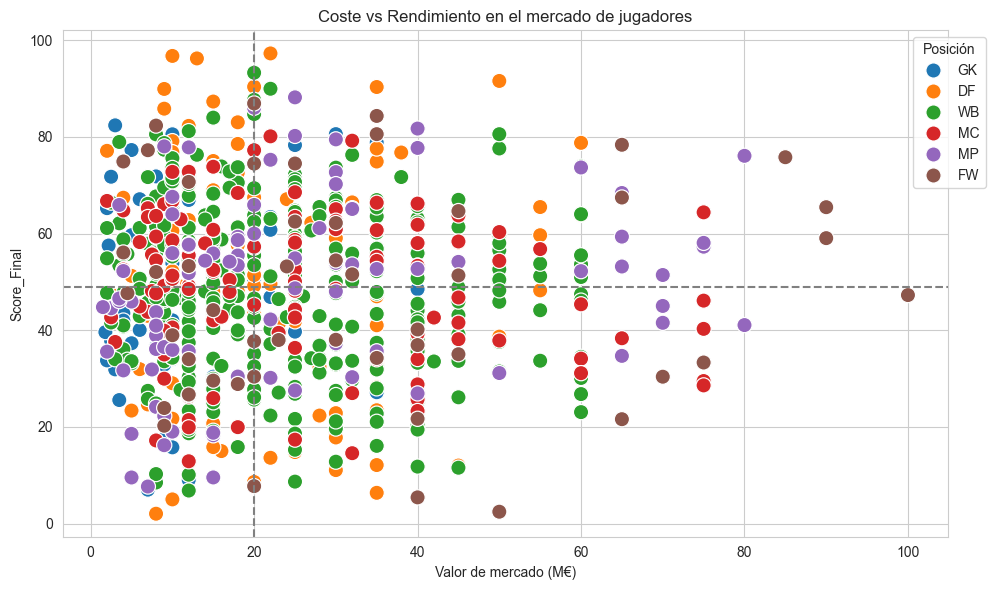

In [ ]:
# =========================================================
# GRÁFICO GLOBAL — COSTE VS RENDIMIENTO (TFM)
# =========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_dash,
    x="Valor_M€",
    y="Score_Final",
    hue="Pos_Model",
    s=120,
    palette="tab10"
)

plt.axhline(df_dash["Score_Final"].median(), linestyle="--", color="gray")
plt.axvline(df_dash["Valor_M€"].median(), linestyle="--", color="gray")

plt.title("Coste vs Rendimiento en el mercado de jugadores")
plt.xlabel("Valor de mercado (M€)")
plt.ylabel("Score_Final")
plt.legend(title="Posición", bbox_to_anchor=(1.05,1))

plt.tight_layout()

plt.savefig("scatter_coste_rendimiento_TFM.png", dpi=300) 

plt.show()